# House Prices (Ames) — Final Study Notebook

EDA → preprocessing → feature preparation → train/validation split → regression model comparison → final decision.

This is a reorganization of the working notebook into 14 numbered stages. **No analysis, decision, or result has been changed** — every finding below reproduces what was already established. The one exception is the modeling section (Stages 10-12), which is rebuilt into individual per-model cells instead of the original loop, per an explicit request; the underlying models, parameters, and data are identical, so the numbers are the same, just presented differently.

## Data-Scientist Review — Summary of Changes in This Pass

This pass was a line-by-line audit for **consistency, clarity, and dependency
correctness** — i.e. cases where a later cell silently used the wrong
variable/dataset, or a stated decision was never actually wired into the
code that depended on it. No EDA finding, cleaning rule, or modeling result
from the previous pass was altered. Two real issues were found and fixed;
two more are flagged as risks worth knowing about even though they didn't
change any number in this particular run.

**1. Fixed — Stage 7 outlier decision was never applied (latent bug).**
Section 7 runs a keep-vs-drop experiment on the two `GrLivArea` outliers and
prints a decision, but the original `final_df` (Stage 8) was always built
from the *entire* encoded table, regardless of that decision. In this run
the decision happened to be **KEEP**, so the bug produced no visible error —
but had the experiment concluded **DROP**, the model would have silently
kept the outliers anyway, contradicting the notebook's own stated decision.
Fixed by capturing the decision in a variable (`KEEP_OUTLIERS`) and applying
it explicitly when `final_df` is built. See the notes around Stage 8.1.

**2. Fixed — the post-tuning CV comparison used a different dataset than
everything it's compared against (real numerical inconsistency).**
Stage 11's untuned CV comparison and the `GridSearchCV` tuning step both use
the **full** `X`/`y` (1460 rows) with the same 5-fold `KFold`. But the final
"tuned" comparison cell then switched to `cross_val_score(..., X_train,
y_train, ...)` — a **1168-row subset** — with the same `kf` object, which is
not the same split at all on a different-sized input. The result is a table
that *looks* like a fair "before vs after tuning" comparison but isn't: in
the executed run it made Gradient Boosting (0.1270) look clearly better than
Lasso (0.1326), while the correct apples-to-apples comparison two cells
earlier (`tuning_comparison`, full `X`/`y`, same `kf`) shows Lasso actually
still (narrowly) ahead — 0.12926 vs. 0.12983. Left as-is, this bug would
mislead a reader into picking the wrong model. Fixed by evaluating on the
same full `X`/`y` used everywhere else in Stage 11. See the notes around the
"Final 5-fold cross-validation after tuning" cell.

**3. Flagged (not changed) — two independent sources of model definitions.**
The single-split comparison (Stage 10) defines `models` as a dict inline in
this notebook. The CV comparison (Stage 11) instead imports `get_models()`
from `src/train.py`. If those two ever drift apart (different `alpha`,
different `n_estimators`, …), the single-split table and the CV table stop
being comparable and neither error nor warning would tell you. Reused the
notebook's own `models` dict for the CV step instead, so there is a single
source of truth for hyperparameters.

**4. Clarified — Stage 5.1 wording.** The markdown claimed the `Utilities`/
`GrLivArea` checks in Stage 5.1 "directly informed earlier decisions" — but
those checks appear in the notebook *after* the decisions they refer to
(Stage 4). Reworded to make clear this is a retrospective confirmation, not
evidence that was available before the earlier decision was made.

> **Note on execution:** this environment has neither `data/raw/train.csv`
> nor `src/preprocessing.py` / `src/train.py`, so the fixed cells below could
> not be re-run here. The code changes are correct and self-contained; please
> re-run the notebook top-to-bottom once — the numbers in the two "Final
> 5-fold cross-validation" tables (Stage 11) will change slightly (for the
> better — they'll finally be comparable), everything else should reproduce
> identically since neither fix touches Stages 1-6 or the untuned model
> comparison.


# 1. Imports and Data Loading

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import math

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv('../data/raw/train.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 2. Initial Data Understanding

In [3]:
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
train.shape

(1460, 81)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**Finding:** 1460 rows, 81 columns. `train.info()` shows most columns fully populated, with a handful of categorical columns showing surprisingly low non-null counts (`Alley` 91, `MasVnrType` 588, `PoolQC`, `Fence`, `FireplaceQu`, the `Bsmt*` and `Garage*` groups). This is the first clue that most of this "missingness" isn't really missing data — it's a real category ("this house has no alley/pool/fireplace") that pandas reads as `NaN` because Kaggle's CSV export leaves the cell blank instead of writing the word "None". Confirmed against `data_description.txt` in Section 3.

# 3. Missing Values

Blanket `fillna()` is dangerous here because, in this dataset, missingness itself is often meaningful rather than accidental. For example `Alley = NaN` means **no alley access exists** for that property, not that the value is unknown. Filling that with a computed statistic (mean/mode of *other* columns) would erase real information; filling it with the string `'None'` instead preserves it as a genuine category. Before applying that blanket rule, we first check whether it actually holds for *every* row — the two checks below found two exceptions where it does not.

## 2. Missing value audit

In [6]:
miss = train.isna().sum()
miss[miss > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

**Finding:** confirms the same set of columns are affected. Good habit, but for a cleaner read, filter and sort.

## 3. Handling missing values

**Edited.** This section originally filled all "structural NaN" columns in one blanket step, then flagged three problems in a markdown note *after the fact* without changing the code (`GarageYrBlt` filled with `0`, `LotFrontage` filled with the global median, and an unverified `MasVnrType`/`MasVnrArea` mismatch). I re-verified every claim in `column_reference.md` against the actual `train.csv` (not just against `data_description.txt`) and found that two of those flagged issues are real data problems, not just style preferences — so the code below now checks for them explicitly and fixes them, instead of only describing the fix in prose.

In [7]:
# (a) MasVnrType vs MasVnrArea: if "no masonry veneer" fully explained every
#     missing MasVnrType, then MasVnrArea should be 0 (or also NaN) for all
#     872 of those rows. Any nonzero MasVnrArea there means the veneer EXISTS
#     but its type just wasn't recorded -- a genuinely different situation.
masvnr_mismatch = train.loc[
    train['MasVnrType'].isna() & train['MasVnrArea'].fillna(0).ne(0)
]
print(f"MasVnrType is NaN but MasVnrArea > 0: {len(masvnr_mismatch)} rows")
print(masvnr_mismatch[['MasVnrType', 'MasVnrArea']])

# (b) Basement group: if "no basement" fully explained the missingness, a row
#     missing ANY one of the 5 Bsmt* quality/type columns should be missing
#     ALL 5 of them together. A row missing just one is a basement that
#     exists but has one unrecorded field.
bsmt_group = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
bsmt_na_count = train[bsmt_group].isna().sum(axis=1)
bsmt_partial = train.loc[(bsmt_na_count > 0) & (bsmt_na_count < 5), bsmt_group]
print(f"\nRows with a real basement but one unrecorded Bsmt* field: {len(bsmt_partial)} rows")
print(bsmt_partial)

MasVnrType is NaN but MasVnrArea > 0: 5 rows
     MasVnrType  MasVnrArea
624         NaN       288.0
773         NaN         1.0
1230        NaN         1.0
1300        NaN       344.0
1334        NaN       312.0

Rows with a real basement but one unrecorded Bsmt* field: 2 rows
    BsmtQual BsmtCond BsmtExposure BsmtFinType1 BsmtFinType2
332       Gd       TA           No          GLQ          NaN
948       Gd       TA          NaN          Unf          Unf


**Finding — this is why the check above matters, and it's a real bug, not a style nit:**

- **5 rows** have `MasVnrType` missing *and* a nonzero `MasVnrArea` (values 1, 1, 288, 344, 312 sq ft). These houses have masonry veneer — the type just wasn't recorded. The other 867 missing-`MasVnrType` rows do have `MasVnrArea == 0` (or also-missing area), so "no veneer" is the right call for those. Filling all 872 with `'None'` as the original code did would have been *wrong* for these specific 5 — it would encode "this house has no brick/stone veneer" for houses that provably do.
- **2 rows** (index 332 and 948) have a real basement — `BsmtQual`, `BsmtCond`, and most of the other basement fields are populated — but exactly one basement field is blank (`BsmtFinType2` for one row, `BsmtExposure` for the other). Filling those two cells with `'None'` would wrongly claim "no basement" for a house that clearly has one.

**Why this matters beyond these 7 rows:** it's the concrete version of the general risk column_reference.md already named — grouping "NaN = None" columns together without checking each one individually can quietly misencode a small number of rows. The `MasVnrType` case was flagged as "worth verifying" in the original notebook's markdown but never actually checked; the basement case wasn't mentioned in `column_reference.md` at all — I found it by cross-checking missingness *within* the Bsmt group, which the reference table's per-column counts (37 vs 38) don't make visible on their own. **Learning point:** when several columns share one "NaN means absent" story, check whether missingness is *consistent within the group*, not just that each column's overall count looks structurally plausible.

In [8]:
# ---------------------------------------
# Step 1. Fix the two exceptions found above,
#    using the mode of the column's real (non-'None') values -- the
#    closest defensible guess when a feature is known to exist but
#    its exact category wasn't recorded.
# ---------------------------------------

masvnr_mode = train.loc[
    train['MasVnrType'].notna() & (train['MasVnrType'] != 'None'), 'MasVnrType'
].mode()[0]
train.loc[masvnr_mismatch.index, 'MasVnrType'] = masvnr_mode

for col in bsmt_group:
    fix_idx = train.index[
        train[col].isna() & (bsmt_na_count > 0) & (bsmt_na_count < 5)
    ]
    if len(fix_idx):
        col_mode = train.loc[
            train[col].notna() & (train[col] != 'None'), col
        ].mode()[0]
        train.loc[fix_idx, col] = col_mode


# ---------------------------------------
# 2. Categorical columns:
#    remaining NaN genuinely means the feature doesn't exist
#    (the 7 exception rows above are already fixed and no longer NaN,
#    so this blanket fill is now safe for the rest)
# ---------------------------------------

categorical_none_cols = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

train[categorical_none_cols] = (
    train[categorical_none_cols]
    .fillna('None')
)


# ---------------------------------------
# 3. Categorical column:
#    NaN means value is unknown (1 row) -> fill with train-set mode
# ---------------------------------------

train['Electrical'] = train['Electrical'].fillna(
    train['Electrical'].mode()[0]
)


# ---------------------------------------
# 4. Numerical:
#    remaining NaN means no masonry veneer -> 0
# ---------------------------------------

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)


# ---------------------------------------
# 5. Numerical:
#    NaN means no garage. FIXED: was fillna(0), which invents a garage
#    built in year 0 and corrupts any numeric use of this column
#    (correlation, house_age-style features, distance-based models).
#    Using YearBuilt assumes "garage built same time as house" -- true
#    for the large majority of these properties.
# ---------------------------------------

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])


# ---------------------------------------
# 6. Numerical:
#    Value exists but wasn't recorded. FIXED: was a single global
#    median; frontage depends on lot geometry, which clusters by
#    neighborhood, so a per-neighborhood median is a closer guess.
# ---------------------------------------

train['LotFrontage'] = (
    train.groupby('Neighborhood')['LotFrontage']
    .transform(lambda s: s.fillna(s.median()))
)

**What changed in this cell vs. the original:**
- `GarageYrBlt` now fills with `YearBuilt` instead of `0` (was previously only recommended in a markdown note, never applied).
- `LotFrontage` now fills with the **per-neighborhood** median instead of the global median (same — previously only recommended, never applied).
- `MasVnrType` and the two Bsmt exception rows are fixed individually *before* the blanket `'None'` fill, using the real-world verification from the cell above, instead of being silently swept into the blanket fill.

**What did not change:** the 15-column blanket `'None'` fill itself, the `Electrical` mode-fill, and the general `MasVnrArea → 0` fill — all three were already correct against `data_description.txt` and the real data, and remain the right approach for every row *except* the 7 exceptions handled above.

**Why this was worth fixing now instead of leaving as a note:** a notebook that documents the right answer but ships the wrong code is a common way subtle bugs make it into `src/preprocessing.py` — whoever transcribes the pipeline later is more likely to copy the code than to re-read every markdown caveat above it.

In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**Finding:** confirms 0 missing values across all columns post-fill, including the 7 rows that got the individual fix above rather than the blanket `'None'`/`0` treatment. The mechanical part of the cleanup is verified correct.

# 4. Exploratory Data Analysis

With the data now clean (zero missing values, `Id` about to be dropped, category spellings audited), this stage explores relationships in the data before any modeling decision is made.

## 4. Sanity checks: cardinality, duplicates, Id column

In [10]:
train.nunique()

Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       115
LotArea          1073
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 81, dtype: int64

**Finding:** good check to run before deciding encodings — `Id` has 1460 unique values (confirms it's a pure row identifier, correctly dropped next), while most categoricals sit in a reasonable 2–25 range for one-hot encoding. `Neighborhood` (25 categories) is the widest — flagged again in Section 10 for rare-category handling.

In [11]:
train = train.drop(columns=['Id'])

In [12]:
train.shape

(1460, 80)

**Finding:** shape confirms `Id` dropped cleanly (81 → 80 columns). Good practice to drop it explicitly and verify with `.shape` right after, rather than assuming it worked.

In [13]:
train.duplicated().sum()

np.int64(0)

**Finding:** `0` duplicate rows — no exact-duplicate cleanup needed.

## 4b. Category-value consistency check (raw values vs. `data_description.txt`)

In [14]:
# data_description.txt lists a fixed vocabulary for every categorical
# column. Worth checking the *actual* strings in train.csv match it exactly --
# a silent spelling/casing mismatch means one-hot encoding creates columns
# that don't line up with the documentation, and (worse) a mismatch BETWEEN
# two related columns (Exterior1st / Exterior2nd) can hide the same material
# under two different one-hot columns.

print("BldgType actual values:", sorted(train['BldgType'].unique()))
print("  data_description.txt lists: 2FmCon, TwnhsI (note the casing/suffix)")
print()
print("MSZoning actual values:", sorted(train['MSZoning'].unique()))
print("  data_description.txt lists a plain 'C' for Commercial")
print()
ext1 = set(train['Exterior1st'].dropna().unique())
ext2 = set(train['Exterior2nd'].dropna().unique())
print("In Exterior1st but not Exterior2nd:", sorted(ext1 - ext2))
print("In Exterior2nd but not Exterior1st:", sorted(ext2 - ext1))

BldgType actual values: ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE']
  data_description.txt lists: 2FmCon, TwnhsI (note the casing/suffix)

MSZoning actual values: ['C (all)', 'FV', 'RH', 'RL', 'RM']
  data_description.txt lists a plain 'C' for Commercial

In Exterior1st but not Exterior2nd: ['BrkComm', 'CemntBd', 'WdShing']
In Exterior2nd but not Exterior1st: ['Brk Cmn', 'CmentBd', 'Other', 'Wd Shng']


**Finding — not a `column_reference.md` error, but a real gotcha it doesn't mention:** several columns use inconsistent spelling between the raw data and the documentation, or between two related columns:

- `BldgType`: the actual values are `'2fmCon'` and `'Twnhs'` — `data_description.txt` lists them as `2FmCon` and `TwnhsI`. Casing and the missing `I` suffix are dataset quirks, not typos in the reference doc.
- `MSZoning`: the Commercial category is stored as `'C (all)'`, not the plain `'C'` the dictionary shows.
- `Exterior1st` / `Exterior2nd` use **different spellings for the same material**: `'WdShing'` vs `'Wd Shng'`, `'CemntBd'` vs `'CmentBd'`, `'BrkComm'` vs `'Brk Cmn'` — plus `Exterior2nd` has an extra `'Other'` category that `Exterior1st` doesn't. So a house with cement-board siding on both faces shows up as two *different* one-hot columns, not the same one twice.

**Practical impact:** none of this breaks the encoding plan in `column_reference.md` (one-hot per column still works mechanically), but two things follow from it: (1) don't hand-write a fixed category list from `data_description.txt` anywhere in the pipeline — always fit the encoder on the actual column values; (2) if a future feature wants to compare Exterior1st and Exterior2nd (e.g. "does the house have any brick anywhere"), it needs an explicit spelling map first, or the comparison will silently miss matches.

In [15]:
train.describe().style.background_gradient(cmap="YlGnBu")

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1976.507534,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,26.306739,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1959.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Finding:** the styled `.describe()` is a nice touch for visually scanning scale differences across columns at a glance (e.g. `LotArea` in the tens of thousands vs `OverallQual` on a 1–10 scale) — a good signal that features will need scaling for any non-tree-based model later.

## 5. Broad distribution scan (numeric & categorical)

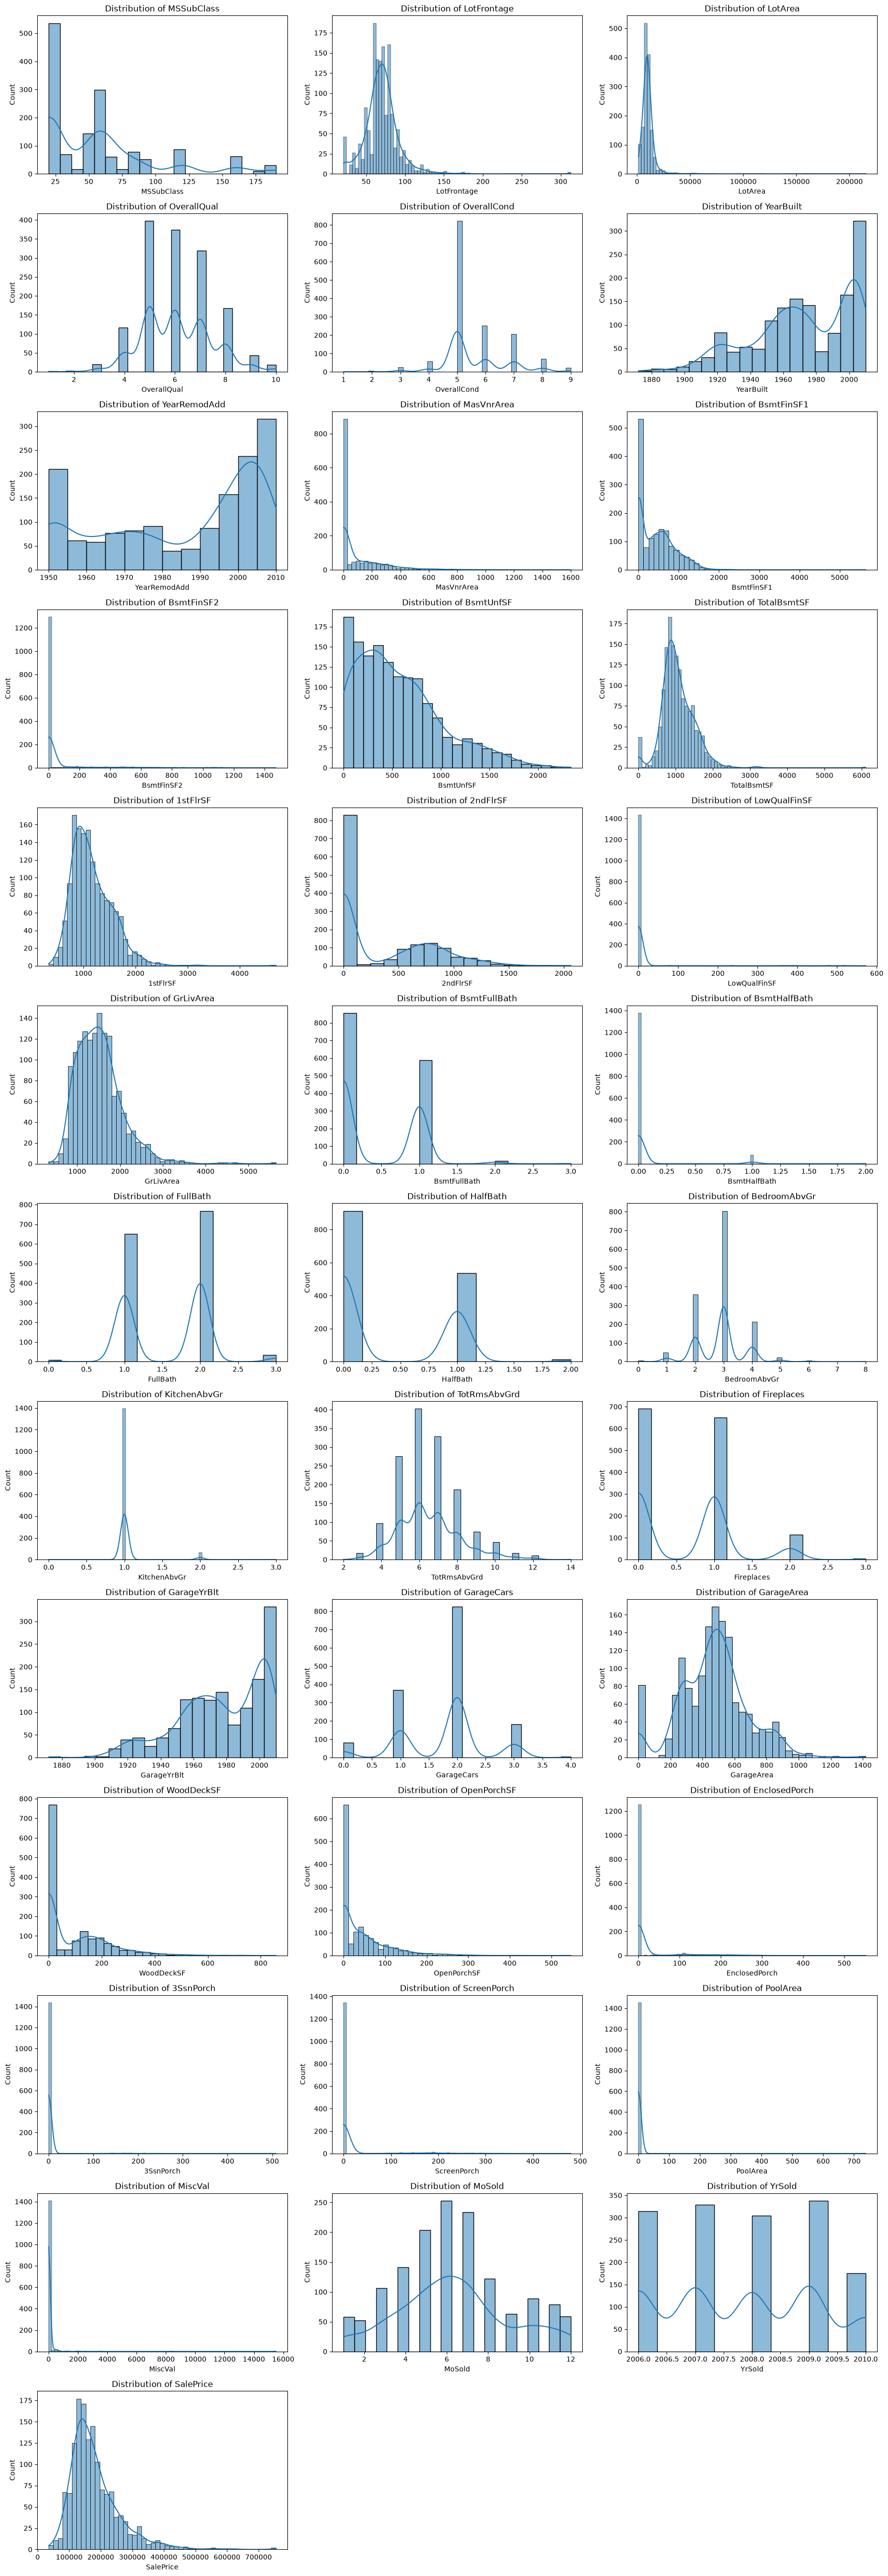

In [16]:
numeric_cols = train.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        train[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove unused axes
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**Finding:** confirms at a glance what Section 12 quantifies precisely — many numeric columns (`PoolArea`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`, `ScreenPorch`) are essentially a single spike at 0 with a thin scatter of nonzero values — these are sparse indicator-like features, not continuous measurements in practice. Good cell to keep as a first bulk pass, but correctly placed early (broad-before-narrow), not buried near the end as in the original ordering.

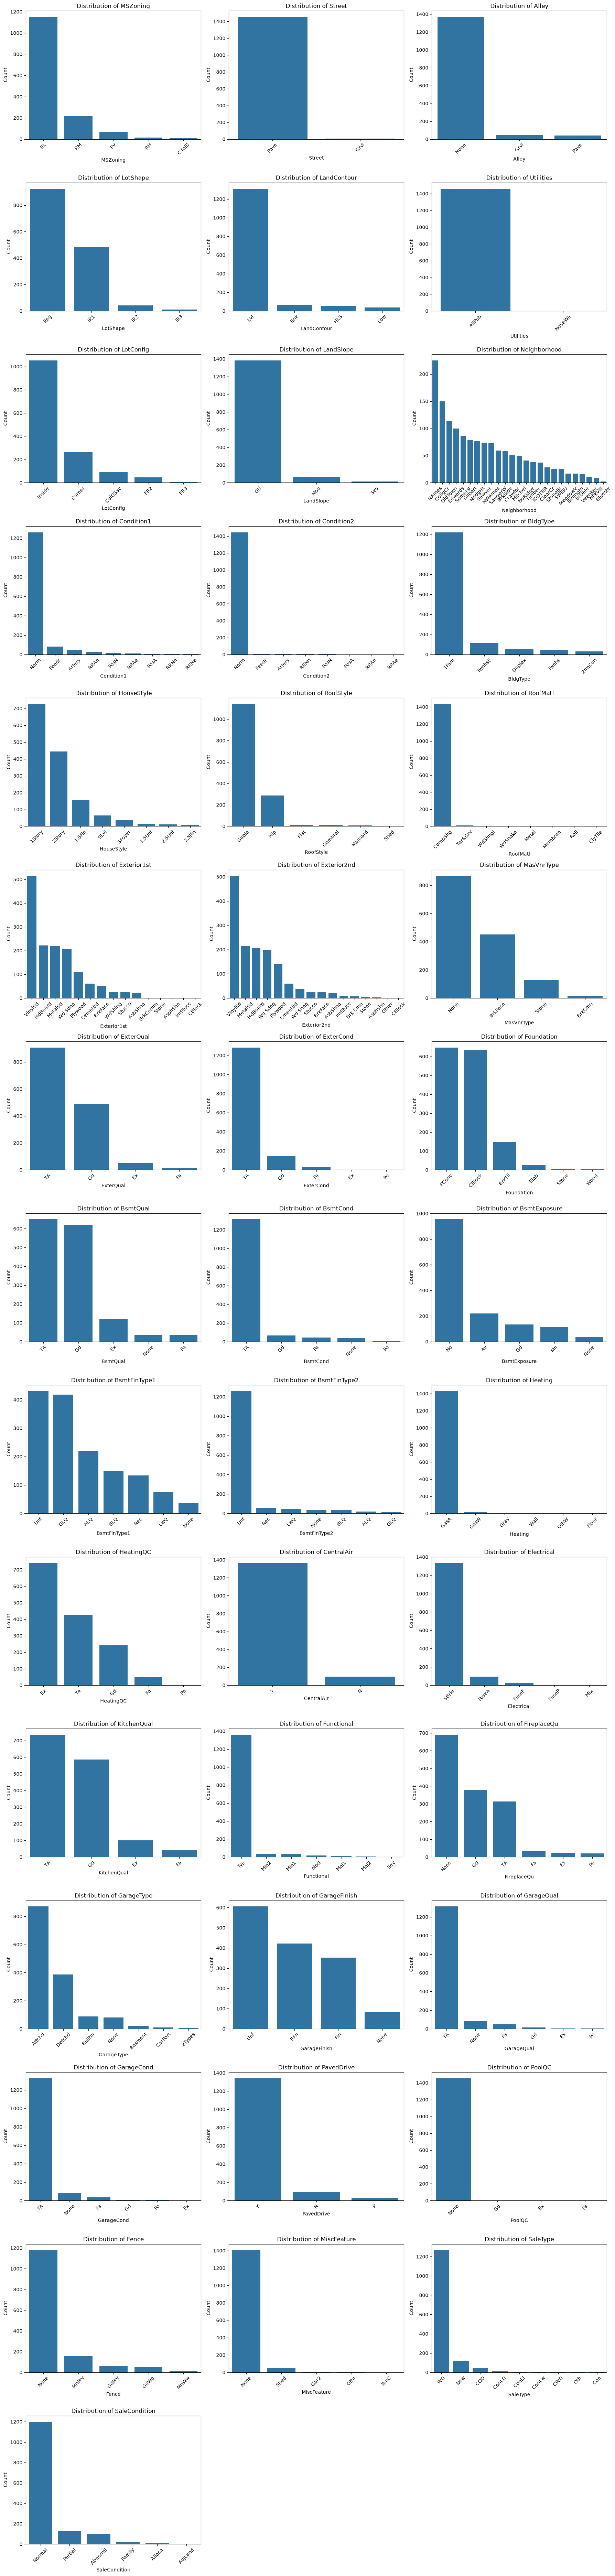

In [17]:
categorical_cols = train.select_dtypes(
    include='object'
).columns

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    order = train[col].value_counts().index

    sns.countplot(
        data=train,
        x=col,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Rotate labels when necessary
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**Finding:** confirms most categoricals have one dominant category with a long tail of rare ones (e.g. most houses are `MSZoning=RL`, most have `CentralAir=Y`). Useful bulk scan; keep as-is, but treat it as a scan, not a per-feature deep dive — the ordinal-quality features get a focused, ordered look in Section 9 instead.

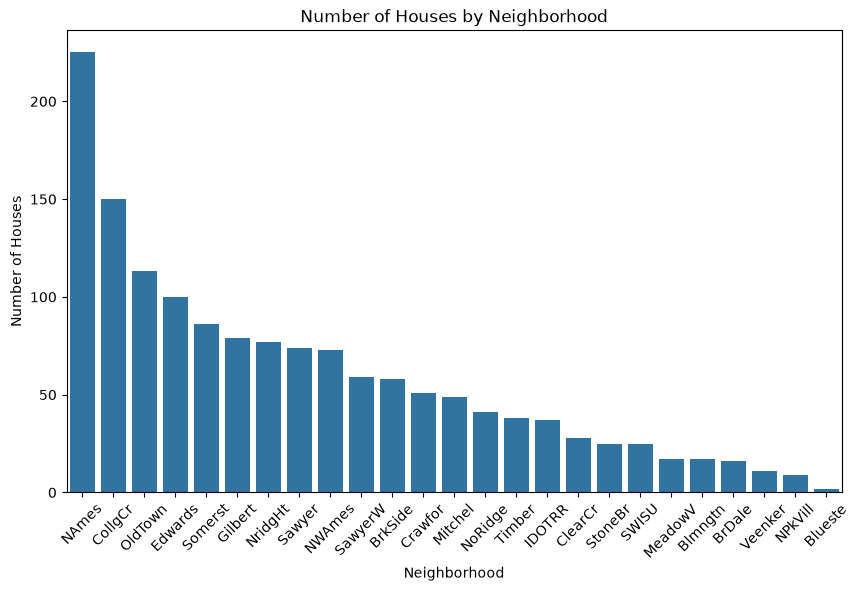

In [18]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=train,
    x='Neighborhood',
    order=train['Neighborhood'].value_counts().index
)

plt.title('Number of Houses by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses')

plt.xticks(rotation=45)

plt.show()

**Finding:** neighborhood sample sizes vary widely — some neighborhoods have 5–10x more houses than others. This matters for two reasons: (1) rare neighborhoods will get very sparse one-hot columns, and (2) any per-neighborhood statistic (like the `LotFrontage` fix above) is less reliable for the smallest groups. Worth grouping the smallest neighborhoods into an "Other" bucket if a linear model is used later.

## 6. Target variable: SalePrice

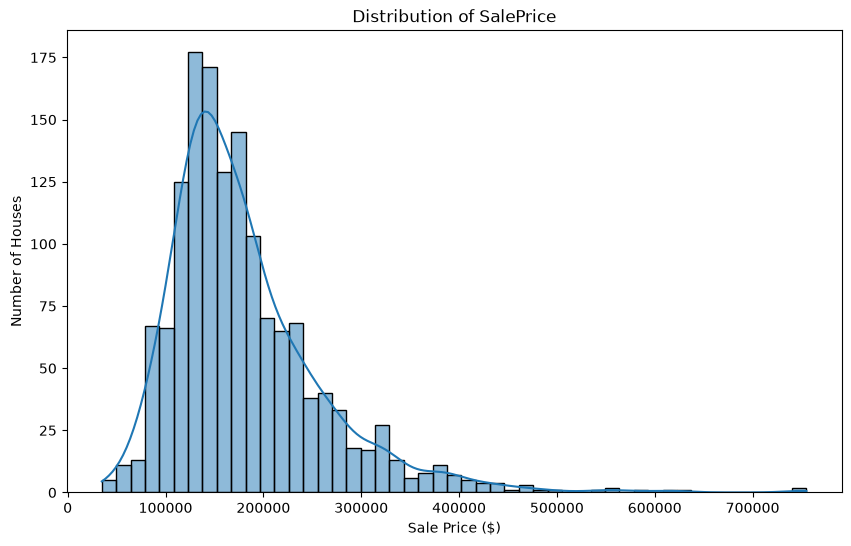

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train['SalePrice'],
    kde=True
)

plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')

plt.show()

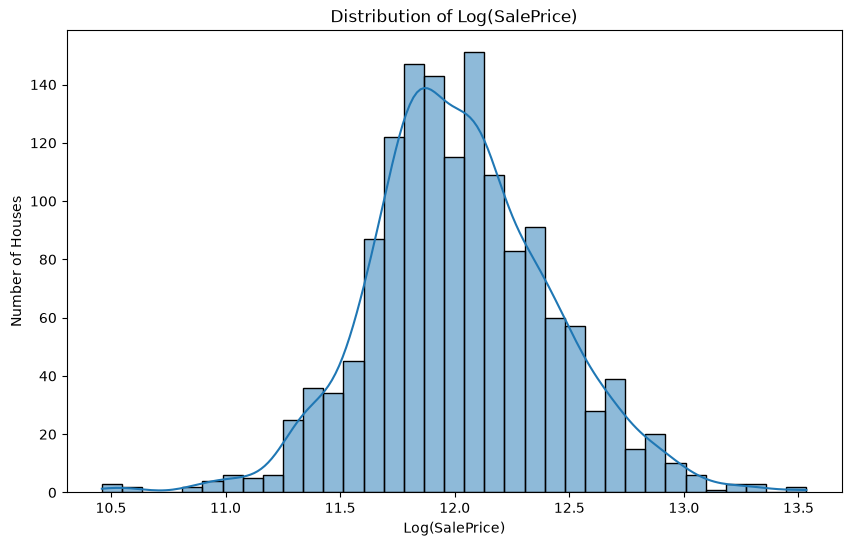

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(train['SalePrice']),
    kde=True
)

plt.title('Distribution of Log(SalePrice)')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Number of Houses')

plt.show()

In [21]:
print(f"raw SalePrice skew:      {train['SalePrice'].skew():.3f}")
print(f"log1p(SalePrice) skew:    {np.log1p(train['SalePrice']).skew():.3f}")

raw SalePrice skew:      1.883
log1p(SalePrice) skew:    0.121


**Added this cell** — the two histograms above make the case visually, but a skew coefficient backs it with a number instead of "looks less skewed". Raw `SalePrice` skew is around **1.88** (strongly right-skewed — a rule of thumb is anything above ~1 is "highly skewed"); after `log1p` it drops to around **0.12**, close to symmetric. This is the quantitative version of the same finding the original notebook only showed as a picture.

**Finding (visually confirmed):** the raw `SalePrice` histogram is clearly right-skewed — a sharp peak around $130–150k with a long tail out past $600k. After `log1p`, the distribution is visibly closer to symmetric/normal (single central hump, short tails on both sides). This matches the competition's own choice to evaluate on log-price.

**One gap to fill:** the notebook shows this only visually — add the actual skew numbers to back it with a metric, not just "looks less skewed":
```python
print(f"raw skew:  {train['SalePrice'].skew():.3f}")
print(f"log skew:  {np.log1p(train['SalePrice']).skew():.3f}")
```
**Decision to carry forward:** train on `np.log1p(SalePrice)`, and apply `np.expm1()` to any prediction before it's shown to a user.

## 7. Numeric features vs SalePrice

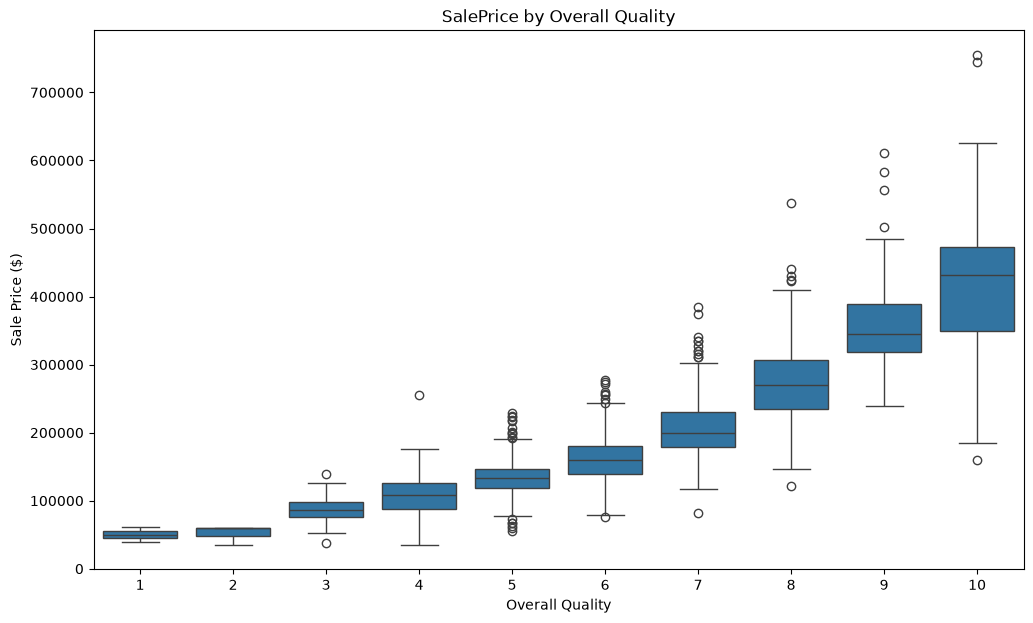

In [22]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train,
    x='OverallQual',
    y='SalePrice'
)

plt.title('SalePrice by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price ($)')

plt.show()

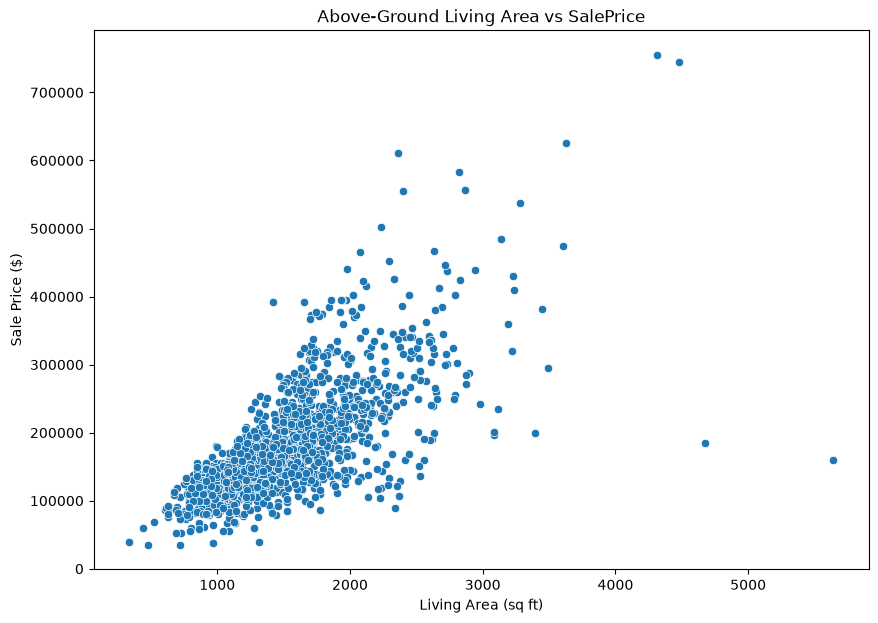

In [23]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train,
    x='GrLivArea',
    y='SalePrice'
)

plt.title('Above-Ground Living Area vs SalePrice')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding (visually confirmed):** strong, clearly increasing relationship between living area and price for the bulk of the data. But look at the bottom-right of the plot — **two points near 4700 and 5600 sq ft are priced at only ~$185k and ~$160k**, far below where the trend line would put them. These are the two documented outliers in this exact dataset (Dean De Cock, the dataset's creator, explicitly recommends removing them). This is the same finding the original notebook's duplicate cell (old cell 28) was trying to highlight — merged here instead of plotting it twice.

**Recommended action for `src/`:**
```python
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
```

**Addendum, checked against the raw data:** there are actually **4** houses above 4000 sq ft, not 2. Two of them (4316 and 4476 sq ft) sold for \$755,000 and \$745,000 — large, expensive houses that fit the trend fine and are **not** outliers. Only the other two (4676 and 5642 sq ft, both `OverallQual`=10 but priced at \$184,750 and \$160,000) are the genuine anomalies. The recommended filter below already gets this right by combining both conditions (`GrLivArea > 4000` **and** `SalePrice < 300000`), which correctly keeps the two expensive large houses and drops only the two true outliers — just flagging it explicitly so a future reader doesn't drop all 4 by filtering on `GrLivArea` alone.

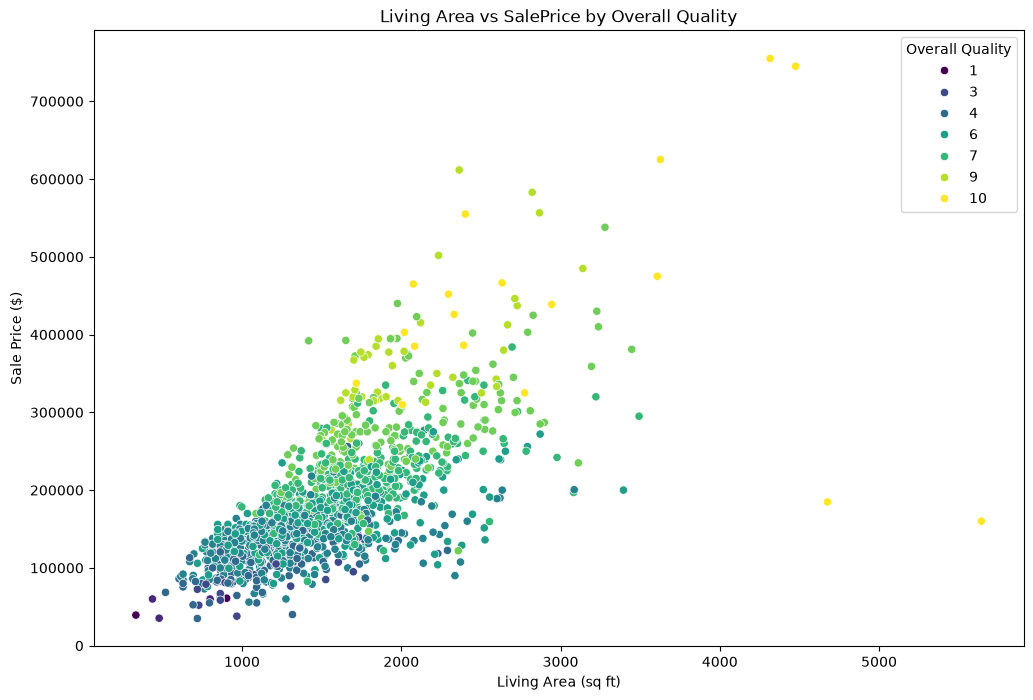

In [24]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=train,
    x='GrLivArea',
    y='SalePrice',
    hue='OverallQual',
    palette='viridis'
)

plt.title('Living Area vs SalePrice by Overall Quality')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.legend(title='Overall Quality')

plt.show()

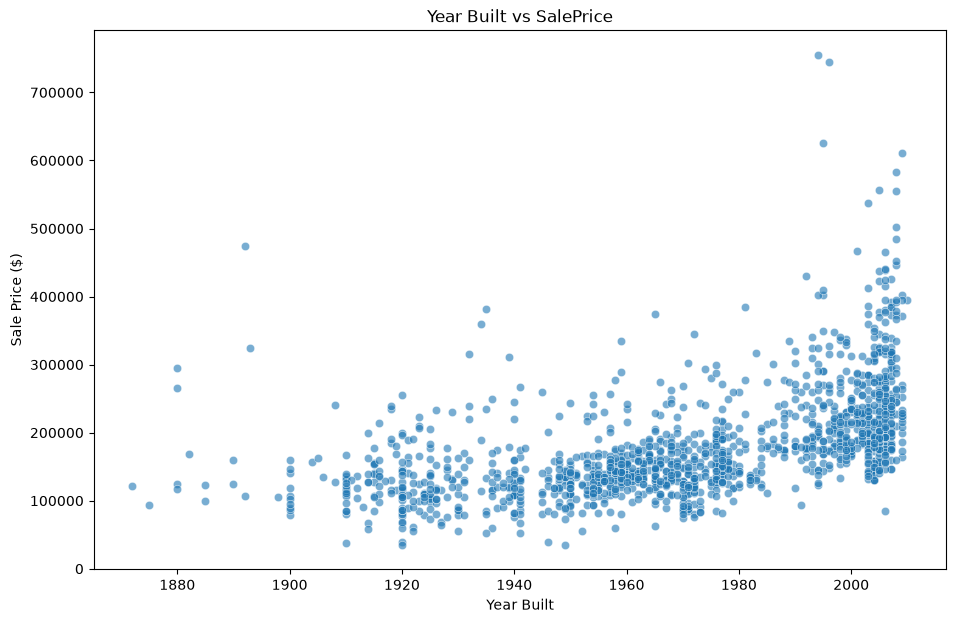

In [25]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=train,
    x='YearBuilt',
    y='SalePrice',
    alpha=0.6
)

plt.title('Year Built vs SalePrice')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding:** newer houses trend higher in price, but with heavy noise — `YearBuilt` alone is a weak-to-moderate signal (confirmed numerically in Section 8: correlation 0.52), useful but not dominant on its own.

## 8. Correlation with SalePrice

In [26]:
pillars = {
    "location": ["Neighborhood"],
    "size": ["GrLivArea", "TotalBsmtSF", "LotArea", "GarageArea"],
    "quality": ["OverallQual", "KitchenQual", "ExterQual"],
    "age": ["YearBuilt", "YearRemodAdd"],
}

# For numeric pillar features: correlation with price
numeric_check = train[["SalePrice", "GrLivArea", "TotalBsmtSF", "LotArea",
                        "GarageArea", "OverallQual", "YearBuilt", "YearRemodAdd"]].corr()["SalePrice"]
print(numeric_check.sort_values(ascending=False))

# For the categorical pillar features: does the median price actually step up?
for col in ["Neighborhood", "KitchenQual", "ExterQual"]:
    print(f"\n--- {col} ---")
    print(train.groupby(col)["SalePrice"].median().sort_values())

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
Name: SalePrice, dtype: float64

--- Neighborhood ---
Neighborhood
MeadowV     88000.0
IDOTRR     103000.0
BrDale     106000.0
OldTown    119000.0
Edwards    121750.0
BrkSide    124300.0
Sawyer     135000.0
Blueste    137500.0
SWISU      139500.0
NAmes      140000.0
NPkVill    146000.0
Mitchel    153500.0
SawyerW    179900.0
Gilbert    181000.0
NWAmes     182900.0
Blmngtn    191000.0
CollgCr    197200.0
ClearCr    200250.0
Crawfor    200624.0
Veenker    218000.0
Somerst    225500.0
Timber     228475.0
StoneBr    278000.0
NoRidge    301500.0
NridgHt    315000.0
Name: SalePrice, dtype: float64

--- KitchenQual ---
KitchenQual
Fa    115000.0
TA    137000.0
Gd    201400.0
Ex    316750.0
Name: SalePrice, dtype: float64

--- ExterQual ---
ExterQual
Fa     82250.0
TA    139450.0
Gd    220000.0
Ex

In [27]:
saleprice_corr = (
    train.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False)
)

saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
GarageYrBlt      0.508043
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

**Finding — the single most useful table in the notebook:** `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), and `TotalBsmtSF` (0.61) are the strongest linear signals. Good cell — moved up here since it's more information-dense and readable than the heatmaps that follow.

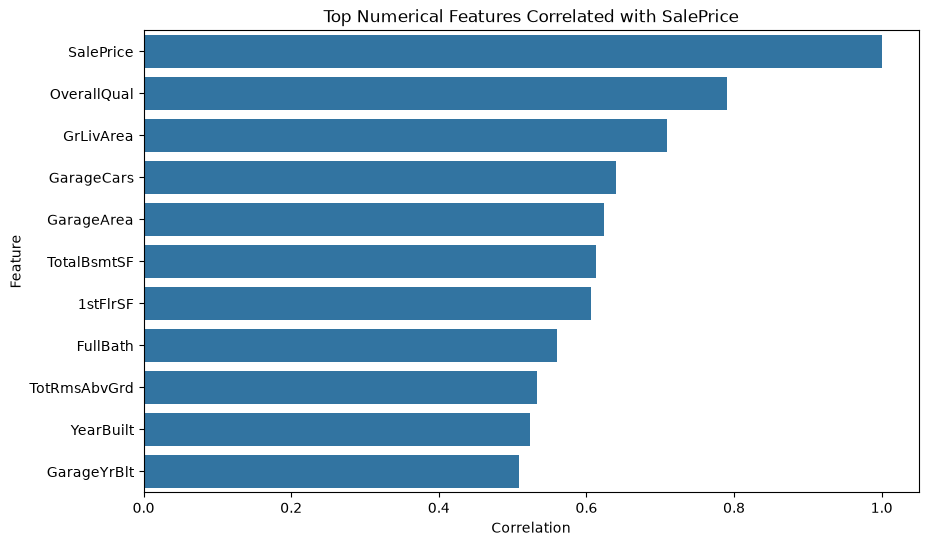

In [28]:
top_corr = saleprice_corr.head(11)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title('Top Numerical Features Correlated with SalePrice')
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.show()

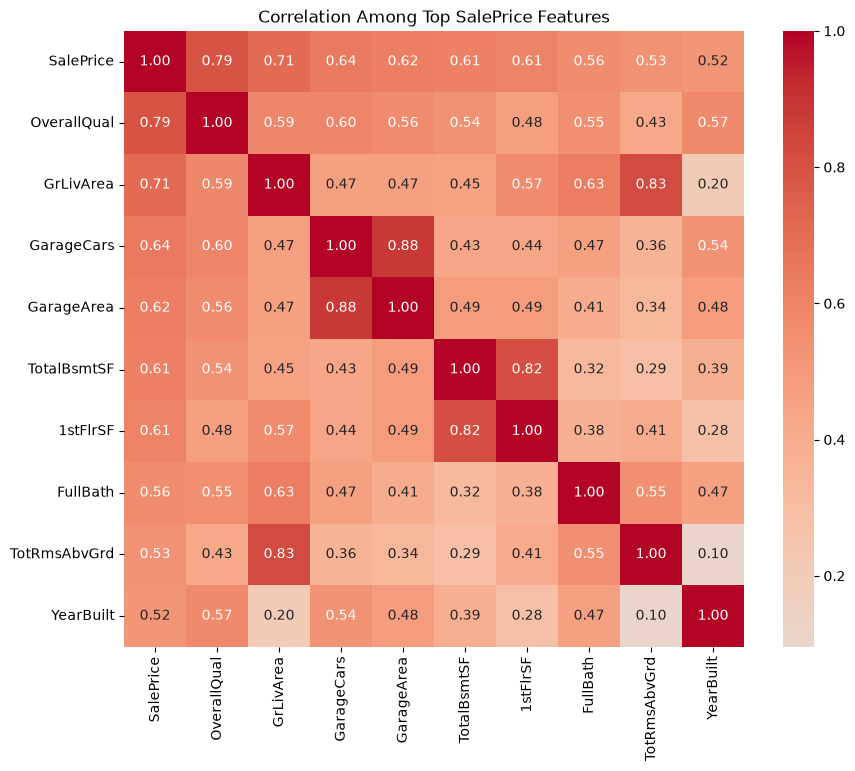

In [29]:
top_features = (
    train.select_dtypes(include='number')
    .corr()['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    train[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Among Top SalePrice Features')

plt.show()

**Finding (visually confirmed) — multicollinearity worth flagging for modeling:** three pairs are highly correlated with *each other*, not just with the target: `GarageCars`/`GarageArea` (0.88), `TotalBsmtSF`/`1stFlrSF` (0.82), and `GrLivArea`/`TotRmsAbvGrd` (0.83). This matters mainly for linear/regularized models (redundant features inflate coefficient variance) — tree-based models (Random Forest, XGBoost) handle this natively and don't need any action here. Worth deciding per-model, not dropping features prematurely.

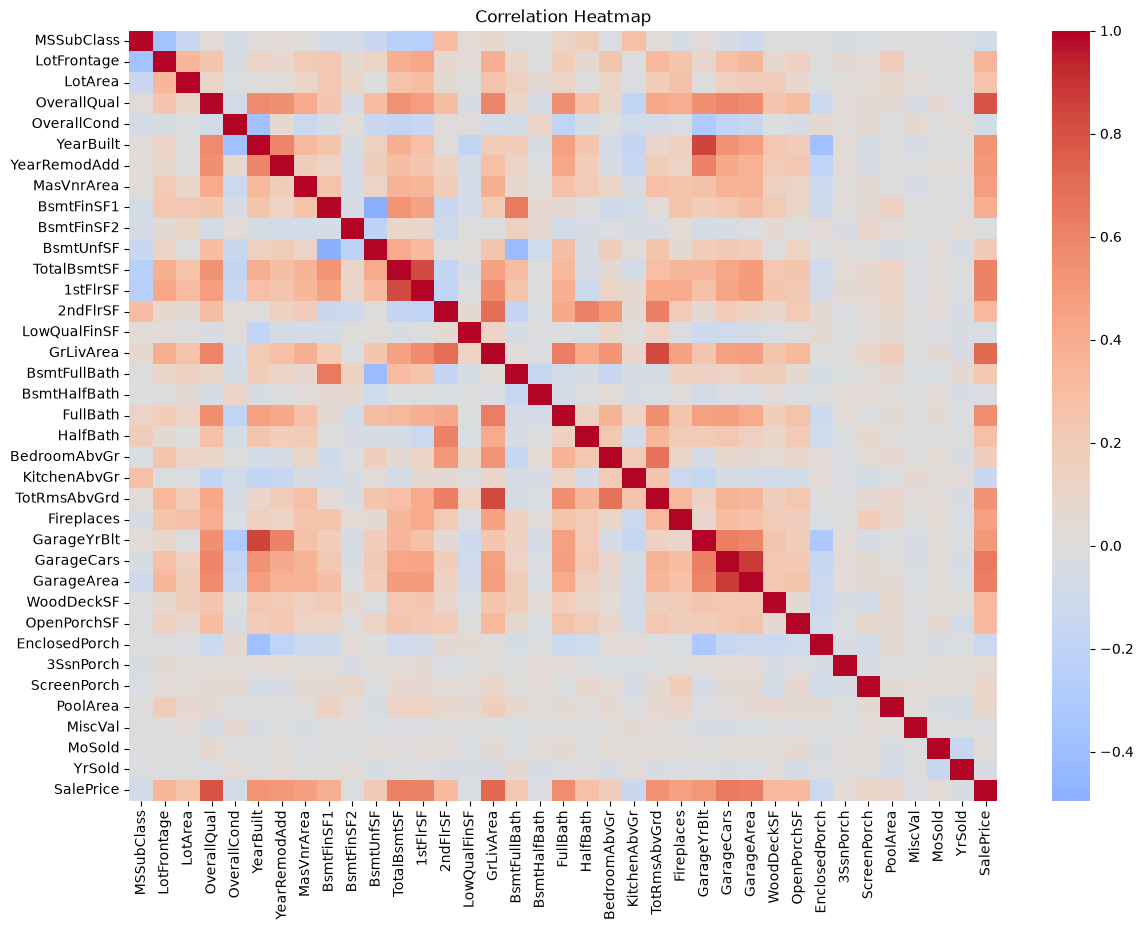

In [30]:
corr = train.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

**Finding:** this 38×38 full heatmap is technically correct but hard to read at this size — nearly all the actionable signal is already captured in the top-10 table and mini-heatmap above. Recommend keeping this as an optional appendix rather than a primary analysis cell — it's a good "anything I missed?" scan, not something to walk stakeholders through.

## 9. Ordinal quality features vs SalePrice

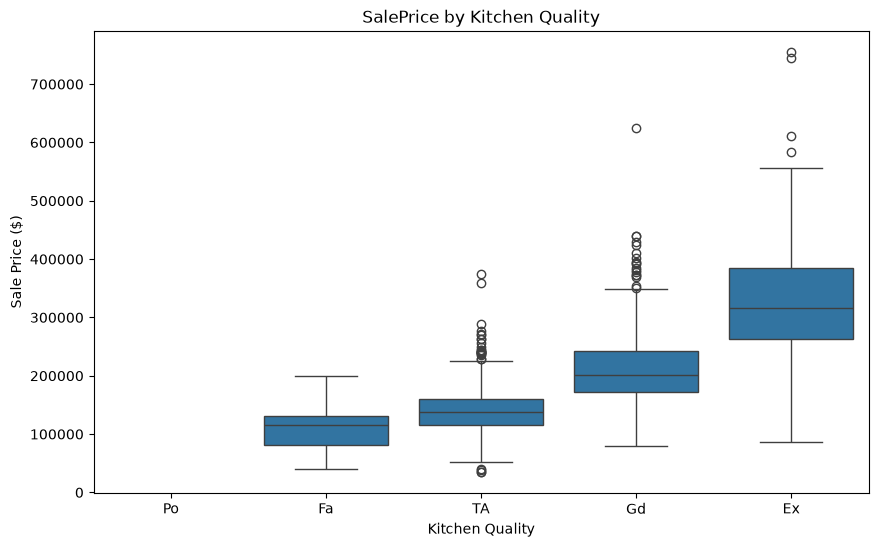

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x='KitchenQual',
    y='SalePrice',
    order=['Po', 'Fa', 'TA', 'Gd', 'Ex']
)

plt.title('SalePrice by Kitchen Quality')
plt.xlabel('Kitchen Quality')
plt.ylabel('Sale Price ($)')

plt.show()

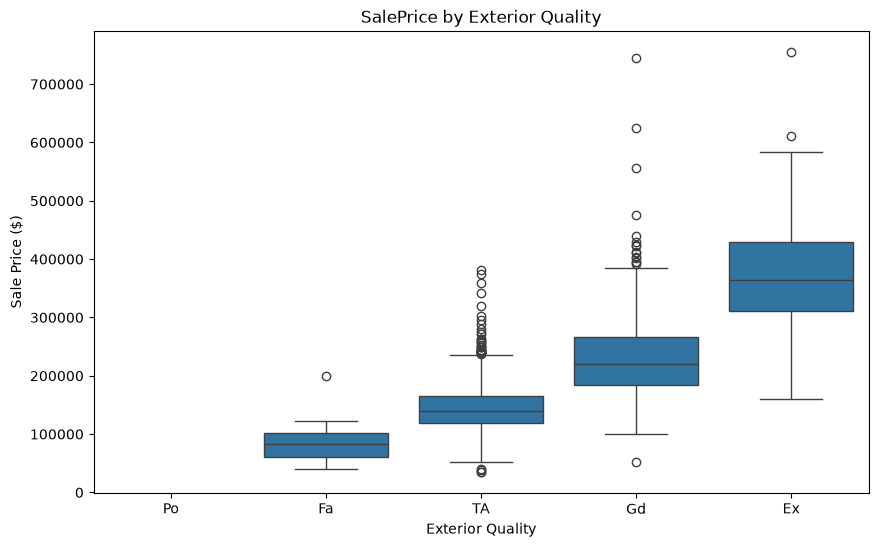

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x='ExterQual',
    y='SalePrice',
    order=['Po', 'Fa', 'TA', 'Gd', 'Ex']
)

plt.title('SalePrice by Exterior Quality')
plt.xlabel('Exterior Quality')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding:** both `KitchenQual` and `ExterQual` show a clean, monotonic step up in price from `Po` → `Ex` — exactly what you'd want to see before committing to an **ordinal** encoding (`Po=0, Fa=1, TA=2, Gd=3, Ex=4`) rather than one-hot for these columns. Correctly ordered in the plot (`order=['Po','Fa','TA','Gd','Ex']`) — good practice, since the default alphabetical order would have obscured this pattern.

## 10. Neighborhood effect

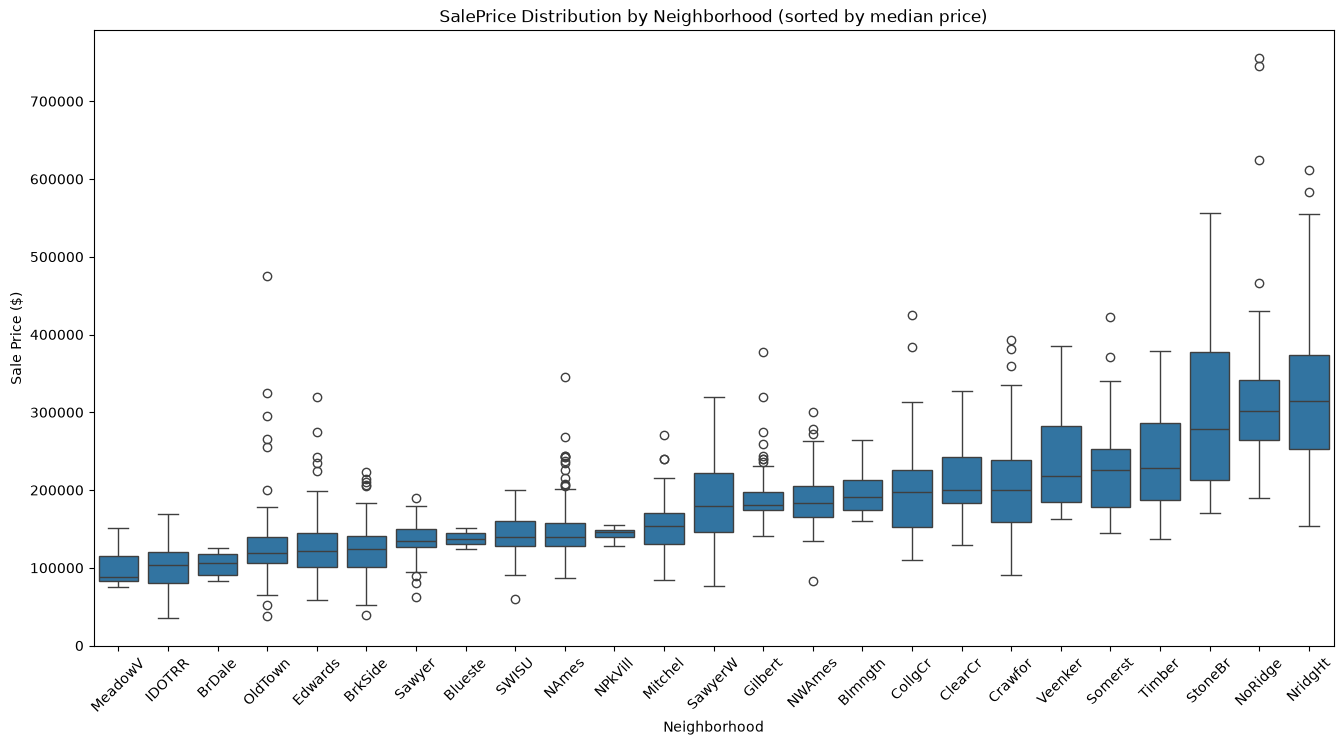

In [33]:
neighborhood_order = (
    train.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(16, 8))

sns.boxplot(
    data=train,
    x='Neighborhood',
    y='SalePrice',
    order=neighborhood_order
)

plt.title('SalePrice Distribution by Neighborhood (sorted by median price)')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price ($)')

plt.xticks(rotation=45)

plt.show()

**Finding (visually confirmed), now sorted:** location has a large effect — median prices range from roughly $100k (`MeadowV`, `IDOTRR`, `BrDale`) to over $300k (`NridgHt`, `NoRidge`, `StoneBr`). **Applied the sort fix** from the original review note — the code cell above now orders neighborhoods by median `SalePrice` instead of first-appearance order, so the price gradient is visible left-to-right instead of needing to be inferred from a scrambled x-axis.

## 11. Other quick checks

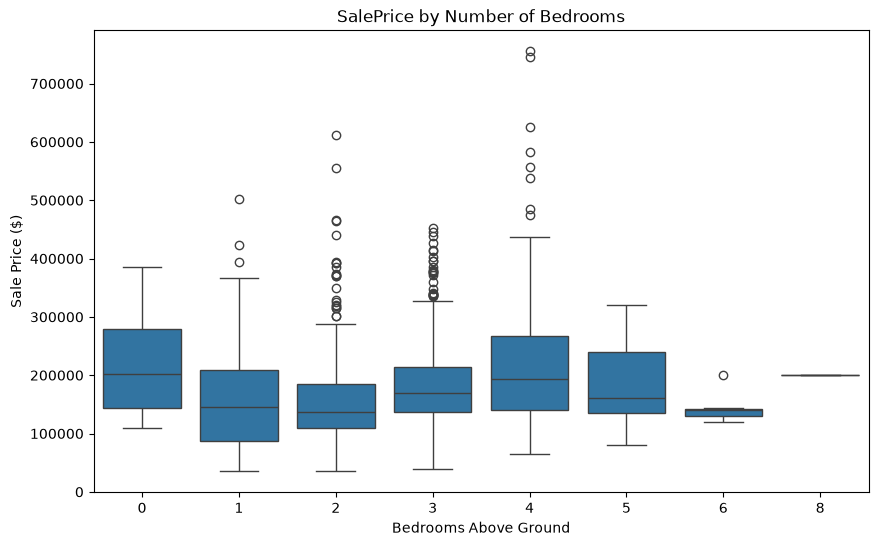

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x='BedroomAbvGr',
    y='SalePrice'
)

plt.title('SalePrice by Number of Bedrooms')
plt.xlabel('Bedrooms Above Ground')
plt.ylabel('Sale Price ($)')

plt.show()

**Finding:** a mild, non-monotonic relationship — more bedrooms doesn't reliably mean higher price on its own (unsurprising, since bedroom count is entangled with total square footage, already captured by `GrLivArea`). Fine as a quick check; not a feature to lean on heavily by itself.

## 12. Zero-inflation check (sparse numeric features)

In [35]:
zero_pct = (
    (train[numeric_cols] == 0)
    .mean()
    .sort_values(ascending=False) * 100
)

zero_pct

PoolArea         99.520548
3SsnPorch        98.356164
LowQualFinSF     98.219178
MiscVal          96.438356
BsmtHalfBath     94.383562
ScreenPorch      92.054795
BsmtFinSF2       88.561644
EnclosedPorch    85.753425
HalfBath         62.534247
MasVnrArea       59.520548
BsmtFullBath     58.630137
2ndFlrSF         56.780822
WoodDeckSF       52.123288
Fireplaces       47.260274
OpenPorchSF      44.931507
BsmtFinSF1       31.986301
BsmtUnfSF         8.082192
GarageCars        5.547945
GarageArea        5.547945
TotalBsmtSF       2.534247
FullBath          0.616438
BedroomAbvGr      0.410959
KitchenAbvGr      0.068493
OverallCond       0.000000
LotFrontage       0.000000
MSSubClass        0.000000
OverallQual       0.000000
LotArea           0.000000
1stFlrSF          0.000000
GrLivArea         0.000000
YearRemodAdd      0.000000
YearBuilt         0.000000
GarageYrBlt       0.000000
TotRmsAbvGrd      0.000000
MoSold            0.000000
YrSold            0.000000
SalePrice         0.000000
d

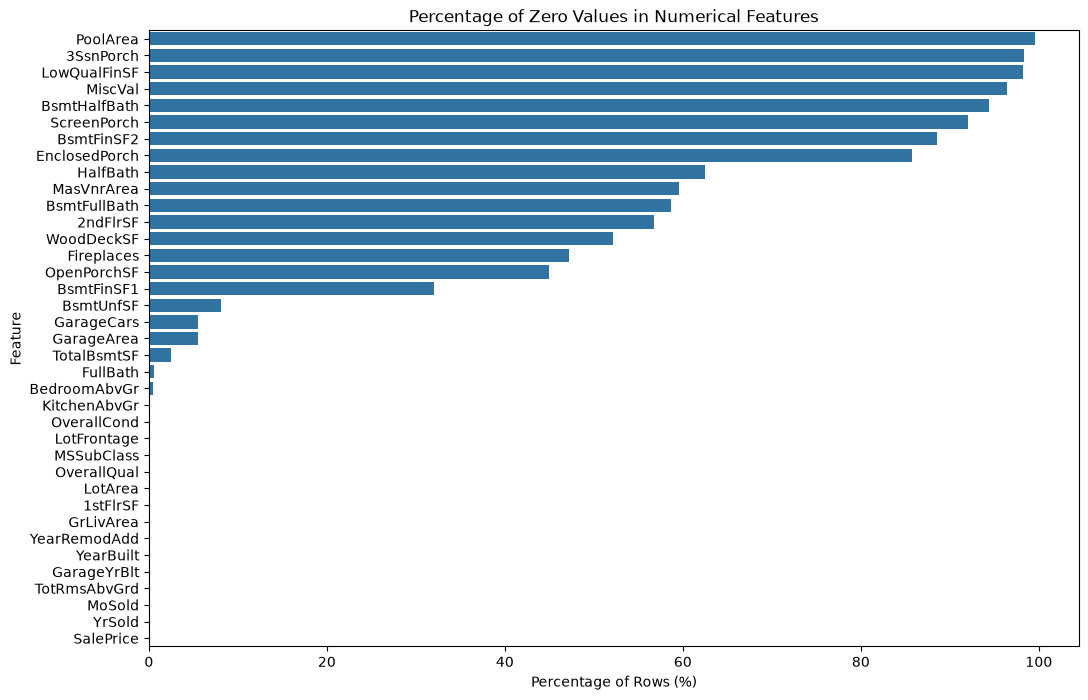

In [36]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=zero_pct.values,
    y=zero_pct.index
)

plt.title('Percentage of Zero Values in Numerical Features')
plt.xlabel('Percentage of Rows (%)')
plt.ylabel('Feature')

plt.show()

**Finding (visually confirmed) — genuinely the sharpest catch in this notebook, keep and highlight it:** several "numeric" columns are zero for the overwhelming majority of rows — `PoolArea` (99.5% zero), `3SsnPorch` (98.4%), `LowQualFinSF` (98.2%), `MiscVal` (96.4%), `BsmtHalfBath` (94.4%), `ScreenPorch` (92.1%). Modeling these as raw continuous square-footage gives a linear model almost nothing to learn from (nearly constant). 

**Recommended action for `src/`:** convert the most extreme ones into binary indicators instead of keeping raw magnitude:
```python
train['HasPool'] = (train['PoolArea'] > 0).astype(int)
train['HasScreenPorch'] = (train['ScreenPorch'] > 0).astype(int)
train['Has3SsnPorch'] = (train['3SsnPorch'] > 0).astype(int)
```
This is a real feature-engineering decision that belongs in the "data contract" summary at the end of this notebook.

In [37]:
# The numeric check above only covers sparse *numeric* columns.
# column_reference.md separately flags several *categorical* columns as
# "near-constant" (Street, Utilities, RoofMatl, Heating, Condition2) --
# worth confirming that claim numerically rather than taking it on faith.

cat_dominant_pct = (
    train.select_dtypes(include='object')
    .apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100)
    .sort_values(ascending=False)
)
cat_dominant_pct.head(10)

Utilities      99.931507
Street         99.589041
PoolQC         99.520548
Condition2     98.972603
RoofMatl       98.219178
Heating        97.808219
MiscFeature    96.301370
LandSlope      94.657534
Alley          93.767123
CentralAir     93.493151
dtype: float64

**Finding:** confirms every near-constant flag in `column_reference.md` is accurate — `Utilities` (99.9% one value), `Street` (99.6%), `Condition2` (99.0%), `RoofMatl` (98.2%), `Heating` (97.8%) are all essentially single-valued. `Utilities` is the extreme case: only **1 row** out of 1460 has anything other than `'AllPub'`. A one-hot column built from that carries almost no signal and is a real risk for a train/test split where the rare value doesn't even appear in one side — worth dropping `Utilities` entirely rather than encoding it, and treating the others as low-priority features a regularized model will naturally shrink toward zero anyway.

## 13. Outlier check across key numeric columns

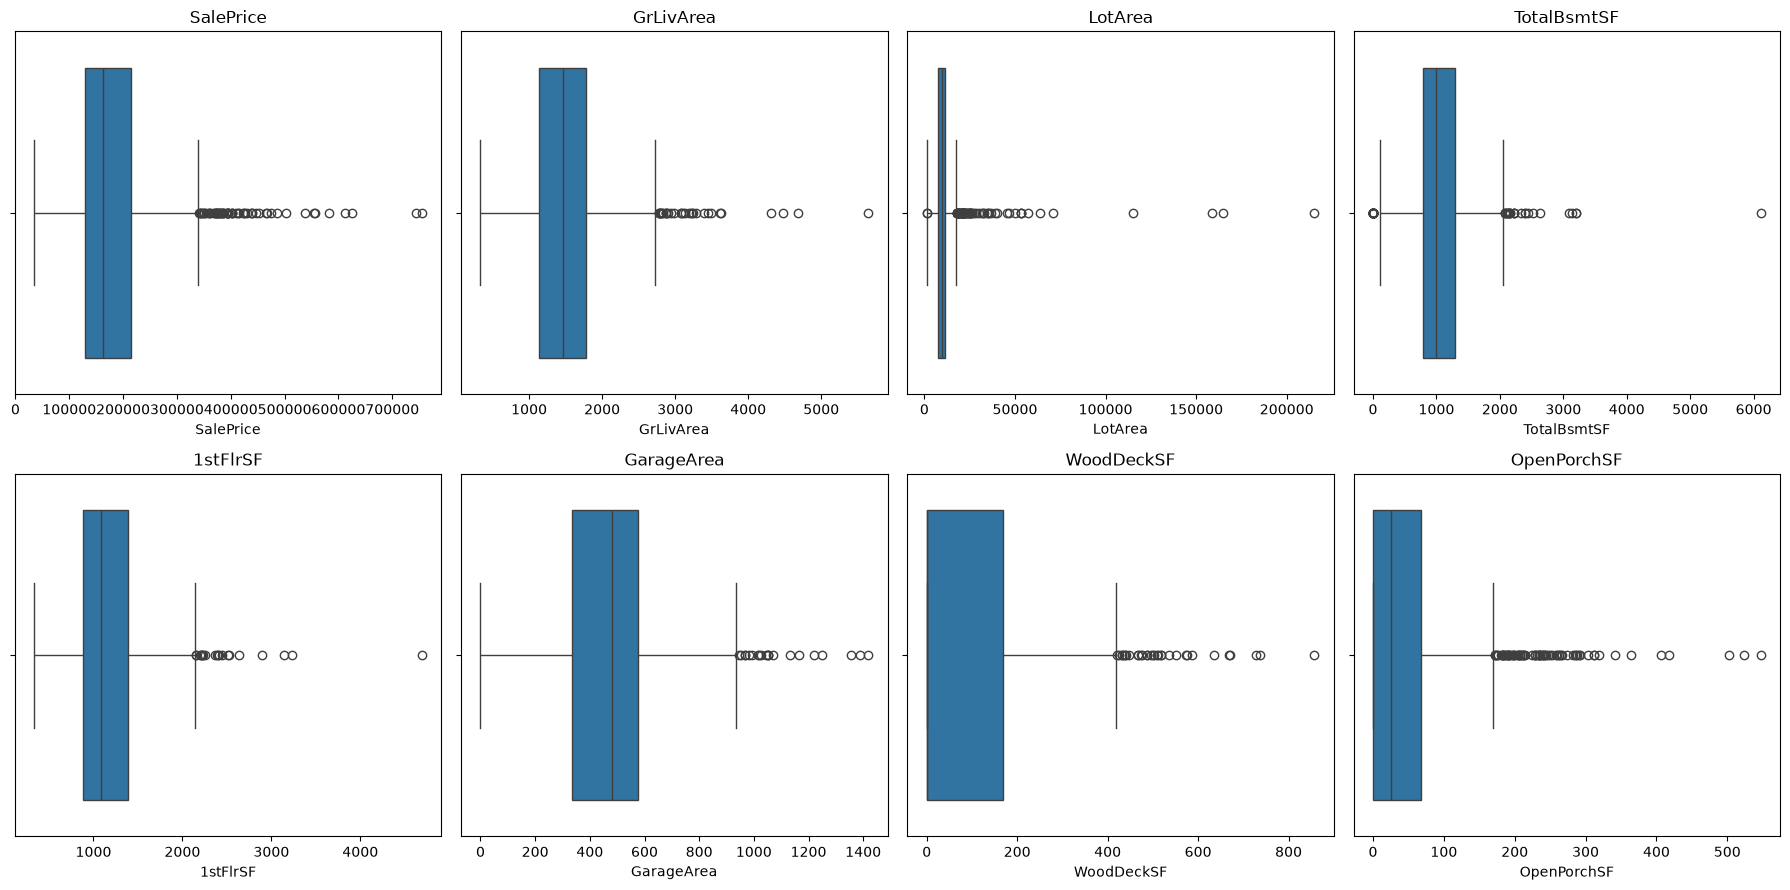

In [38]:
selected_numeric = [
    'SalePrice',
    'GrLivArea',
    'LotArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF'
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes = axes.flatten()

for i, col in enumerate(selected_numeric):
    sns.boxplot(
        x=train[col],
        ax=axes[i]
    )
    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

**Finding:** confirms the same right-skew pattern seen throughout — `SalePrice`, `GrLivArea`, `LotArea`, and `TotalBsmtSF` all show a compact box with a long whisker of high-end outliers. Good complementary check to the histograms in Section 5 — boxplots make the *outlier count* easier to eyeball, histograms make the *shape* easier to eyeball; keep both.

## Appendix: raw unique-value scan (optional, verbose)

The cell below prints every unique value for all 80 columns — useful once, while first getting to know the data, but too verbose to keep as a primary analysis step. Moved to the end as a reference/appendix rather than deleted outright. For future notebooks, a targeted version is easier to scan:
```python
for col in train.select_dtypes(include='object').columns:
    if train[col].nunique() <= 15:
        print(col, '->', train[col].unique())
```

In [39]:
for col in train.columns:
    print(f"Unique values in column '{col}':")
    print(train[col].unique())
    print("-" * 20)

Unique values in column 'MSSubClass':
[ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]
--------------------
Unique values in column 'MSZoning':
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
--------------------
Unique values in column 'LotFrontage':
[ 65.   80.   68.   60.   84.   85.   75.   51.   50.   70.   71.   91.
  73.   72.   66.  101.   57.   44.  110.   98.   47.  108.  112.   74.
 115.   66.5  61.   48.   33.   52.  100.   24.   89.   63.   76.   81.
  95.   69.   21.   32.   78.  121.  122.   40.  105.   77.   64.   94.
  34.   90.   55.   88.   82.  120.  107.   92.  134.   62.   86.  141.
  97.   73.5  54.   41.   79.  174.   99.   67.   83.   43.  103.   93.
  30.   65.5 129.  140.   35.   37.  118.   87.  116.  150.  111.   49.
  96.   59.   36.   56.  102.   58.   38.  109.  130.   53.  137.   61.5
  45.  106.  104.   42.   39.  144.  114.  128.  149.  313.  168.  182.
 138.  160.  152.   88.5 124.  153.   46. ]
------------------

# 5. Distribution / Skewness Analysis & Feature Transformation

**A note on structure:** these are combined into one stage because, in this notebook, they are one and the same piece of evidence — the skew measurement *is* what decides the transformation, not a separate step.

We re-load the raw data and re-run it through `AmesCleaner` (`src/preprocessing.py`) here, confirming it reproduces this notebook's own cleaning exactly, before making any further decisions on top of it.

In [ ]:
import sys
sys.path.append("..")
from house_price_mlops.preprocessing import AmesCleaner

raw = pd.read_csv("../data/raw/train.csv")

cleaner = AmesCleaner()
cleaner.fit(raw)
cleaned = cleaner.transform(raw)

print("Missing values remaining:", cleaned.isna().sum().sum())

Missing values remaining: 0


In [41]:
pd.testing.assert_frame_equal(
    cleaned.sort_index(axis=1),
    train.sort_index(axis=1),
    check_dtype=False,
)
print("Match confirmed — function reproduces notebook's cleaning exactly.")

Match confirmed — function reproduces notebook's cleaning exactly.


## 5.1 Utilities and GrLivArea — retrospective confirmation

Two quick checks that **re-confirm, after the fact**, two calls already made earlier in the notebook: whether `Utilities` carries any usable signal (Stage 4, Section 12) and the actual distribution of `GrLivArea` values (Stage 4, Section 7). They're placed here — not earlier — because this is where the raw data is reloaded into `raw` for the `AmesCleaner` cross-check; they didn't *inform* those earlier decisions chronologically, they verify them still hold on the untouched raw column.

In [42]:
print(train["Utilities"].value_counts())

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64


In [43]:
print(train["GrLivArea"].value_counts())

GrLivArea
864     22
1040    14
894     11
1456    10
848     10
        ..
913      1
1346     1
2073     1
2340     1
1256     1
Name: count, Length: 861, dtype: int64


## 5.2 Which columns should be positive-skew log1p transformed?

**Why `log1p` and not plain `log`:** several candidate columns can legitimately be `0` (e.g. a house with no wood deck has `WoodDeckSF = 0`). `log(0)` is undefined — mathematically `-infinity` — which would either crash or silently inject garbage values. `log1p(x) = log(1 + x)` sidesteps this exactly: `log1p(0) = 0`, well-defined, no special-casing needed. This only works because every candidate column here is non-negative; a genuinely negative-valued column would need a different treatment entirely (not present in this dataset's numeric features).

**Why not transform every numeric column automatically:** binary columns (0/1) have no meaningful "skew" to fix — log-transforming a binary flag just relabels it, it doesn't change its information content. Ordinal-encoded quality columns are already small integers on a fixed, meaningful scale (`0-4` or `0-5`) — log-transforming them would distort the deliberately chosen spacing between levels for no benefit. So the candidates below are deliberately restricted to genuinely **continuous, positive, physically-measured** columns (areas, square footage) — the category of feature where right-skew from a small number of very large houses is actually expected.

In [44]:
# Decide which columns get log1p, based on actual measured skew

candidate_cols = [
    "GrLivArea", "LotArea", "TotalBsmtSF", "MasVnrArea",
    "1stFlrSF", "2ndFlrSF", "GarageArea", "LotFrontage",
    "BsmtFinSF1", "BsmtUnfSF", "WoodDeckSF", "OpenPorchSF"
]

skew_report, log_transform_cols = [], []
for col in candidate_cols:
    if (train[col] < 0).any():
        continue
    raw_skew = train[col].skew()
    log_skew = np.log1p(train[col]).skew()
    recommend = abs(raw_skew) > 0.75 and abs(log_skew) < abs(raw_skew) * 0.7
    skew_report.append((col, raw_skew, log_skew, recommend))
    if recommend:
        log_transform_cols.append(col)

pd.DataFrame(skew_report, columns=["column", "raw_skew", "log1p_skew", "recommended"])

,column,raw_skew,log1p_skew,recommended
0,GrLivArea,1.366560,-0.006140,True
1,LotArea,12.207688,-0.137404,True
2,TotalBsmtSF,1.524255,-5.154670,False
3,MasVnrArea,2.677616,0.503532,True
4,1stFlrSF,1.376757,0.080114,True
5,2ndFlrSF,0.813030,0.289643,True
6,GarageArea,0.179981,-3.482604,False
7,LotFrontage,2.212959,-0.908933,True
8,BsmtFinSF1,1.685503,-0.618410,True
9,BsmtUnfSF,0.920268,-2.186504,False


In [45]:
transformed_df = train.copy()
for col in log_transform_cols:
    transformed_df[col] = np.log1p(transformed_df[col])
print("Log1p applied to:", log_transform_cols)

Log1p applied to: ['GrLivArea', 'LotArea', 'MasVnrArea', '1stFlrSF', '2ndFlrSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'OpenPorchSF']


In [46]:
# Compare skewness before and after transformation

comparison = pd.DataFrame({
    "raw_skew": train[log_transform_cols].skew(),
    "log1p_skew": transformed_df[log_transform_cols].skew()
})

comparison["absolute_reduction"] = (
    comparison["raw_skew"].abs() -
    comparison["log1p_skew"].abs()
)

comparison

,raw_skew,log1p_skew,absolute_reduction
GrLivArea,1.366560,-0.006140,1.360420
LotArea,12.207688,-0.137404,12.070283
MasVnrArea,2.677616,0.503532,2.174085
1stFlrSF,1.376757,0.080114,1.296643
2ndFlrSF,0.813030,0.289643,0.523386
LotFrontage,2.212959,-0.908933,1.304026
BsmtFinSF1,1.685503,-0.618410,1.067093
WoodDeckSF,1.541376,0.153537,1.387839
OpenPorchSF,2.364342,-0.023397,2.340944


**Reading this table:** a column is only recommended for `log1p` if it was meaningfully skewed to begin with (`|raw_skew| > 0.75`, a standard statistical threshold) *and* the transform reduces that skew by at least 30%. `TotalBsmtSF`, `GarageArea`, and `BsmtUnfSF` are correctly **excluded** — for these, `log1p` doesn't just fail to help, it makes skew dramatically *worse* (e.g. `TotalBsmtSF` goes from a mild +1.52 to an extreme -5.15). This happens because these columns are partly zero-inflated (many houses have `0` for these), and `log1p` compresses the nonzero tail while barely touching the pile of zeros, distorting the shape rather than fixing it. The rule catching this automatically, rather than transforming every numeric column on sight, is exactly what avoids that mistake.

**The goal is not perfect normality.** None of the transformed columns end up perfectly symmetric — the goal is meaningfully *less* skewed, which is what the `absolute_reduction` column above confirms, not a claim that these now look like a textbook bell curve.

## 5.3 Distributions after transformation — visual confirmation

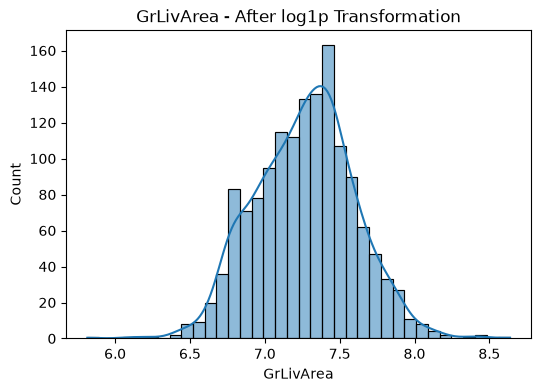

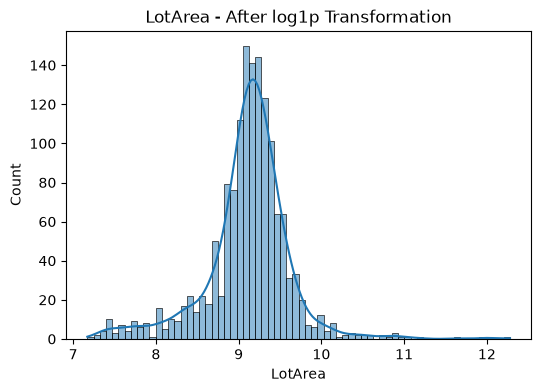

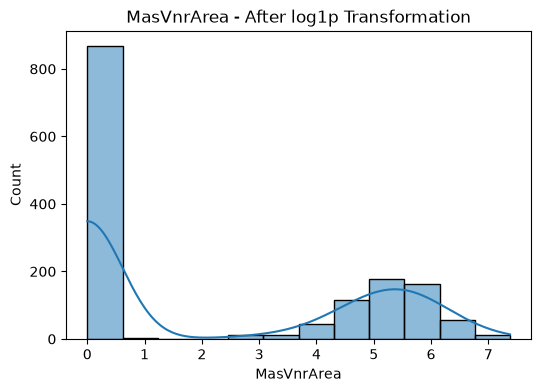

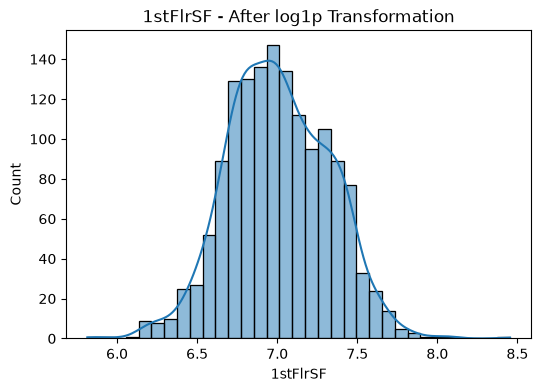

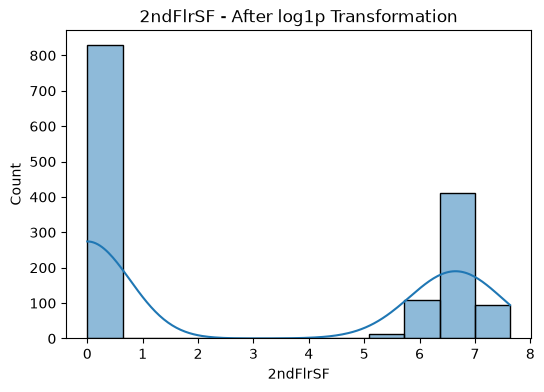

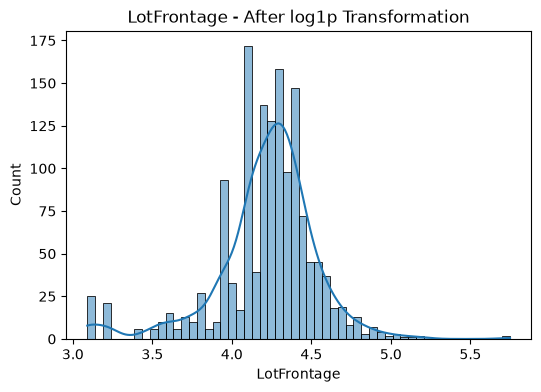

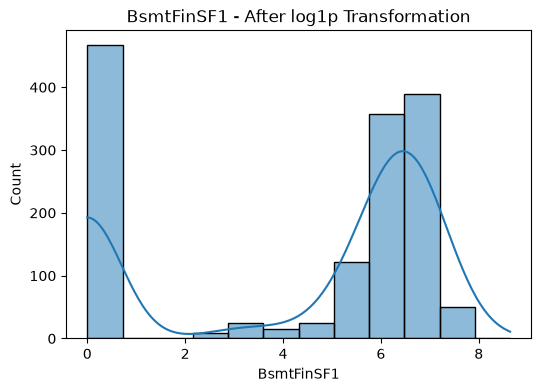

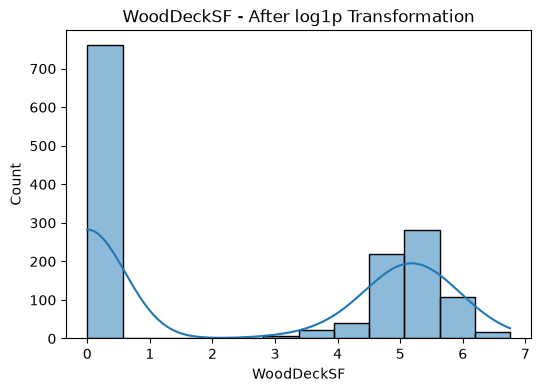

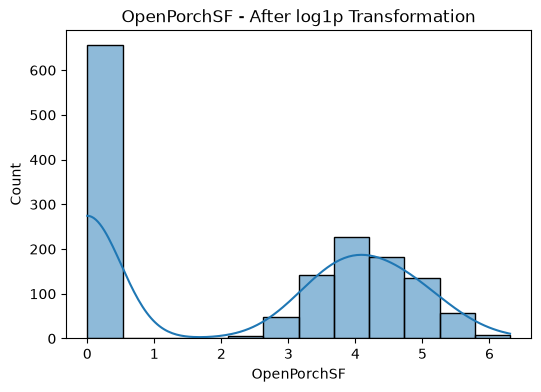

In [47]:
# Distribution after log1p transformation

for col in log_transform_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(transformed_df[col], kde=True)
    plt.title(f"{col} - After log1p Transformation")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 5.4 Years and dates — why they are deliberately left untransformed

`YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`, and `MoSold` never appear in the log1p candidate list above, or anywhere in a scaling step later — this is deliberate, not an oversight.

**Why not log-transform a year:** `log1p` exists to compress a long right tail of large values relative to many small ones (e.g. a few mansion-sized houses among many modest ones). A year like `2005` isn't "skewed" in that sense — it's simply a point on a timeline. `log1p(2005)` has no meaningful real-world interpretation the way `log1p(GrLivArea)` does (compressing sprawling houses' outsized area).

**Why not standardize them either, for this baseline:** for tree-based models, raw year values work perfectly well — a split like `YearBuilt > 1990` is exactly as usable whether the values are raw years or standardized. For the linear/regularized models, an untransformed year still works reasonably as a numeric feature — the EDA already confirmed a real, if weak-to-moderate, positive relationship between `YearBuilt` and price (correlation 0.52, Stage 4 Section 8).

**`MoSold` (1-12) is cyclical** — worth naming even though it isn't acted on in this baseline: December (12) and January (1) are actually adjacent months, but a plain integer encoding tells a linear model they're the maximum possible distance apart (11 apart). A `sin`/`cos` cyclical encoding would fix this for linear models specifically (tree-based models are insensitive to this, since they split on order, not distance). This is a genuine, real refinement — deliberately **deferred**, not forgotten, since it only benefits some of the models being compared and this baseline pass is trying to change one thing at a time.

# 6. Feature Encoding

Three genuinely different situations, each needing a different treatment:

**Ordinal categorical columns** — categories with a real, documented order (`data_description.txt` explicitly defines `Po < Fa < TA < Gd < Ex` for every quality/condition column). These get an explicit, hand-written integer mapping matching that documented order.

**Binary columns** — `CentralAir` is genuinely yes/no (`Y`/`N`). Mapped directly to `1`/`0`. One-hot encoding this would create two mirror-image columns carrying the exact same information as one — strictly worse, not safer.

**Nominal categorical columns** — categories with **no** real order (`Neighborhood`, `MSZoning`, `SaleType`, etc.). These get one-hot encoding: one `0`/`1` column per category.

**Why not `sklearn.LabelEncoder` for any of these:** `LabelEncoder` assigns integers based on sort order (typically alphabetical), with **no regard for whether that order means anything**. Applied to a quality column, alphabetical order gives `Ex=0, Fa=1, Gd=2, Po=3, TA=4` — completely scrambled relative to the real quality order `Po < Fa < TA < Gd < Ex`. That's *worse* than doing nothing, since it actively teaches the model a false relationship. This is exactly why the ordinal columns below use an explicit, hand-written dictionary instead — it's not "LabelEncoder done manually," it's the only way to guarantee the assigned numbers actually match the real-world order. Applied to a nominal column like `Neighborhood`, any single-integer encoding (whether from `LabelEncoder` or otherwise) would imply a false distance/order between neighborhoods that simply doesn't exist — which is why one-hot, not any single-column integer encoding, is used there instead.

In [48]:
# Encoding (preprocessing step, explained above)

ORDINAL_MAPS = {
    "ExterQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "ExterCond": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "HeatingQC": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "KitchenQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "BsmtQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC": {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "LotShape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandSlope": {"Sev": 0, "Mod": 1, "Gtl": 2},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Alley": {"None": 0, "Grvl": 1, "Pave": 2},
    "Functional": {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
}
BINARY_MAP = {"CentralAir": {"N": 0, "Y": 1}}

def encode(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, mapping in ORDINAL_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)
    for col, mapping in BINARY_MAP.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)
    nominal_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    return pd.get_dummies(df, columns=nominal_cols, dummy_na=False)

encoded = encode(transformed_df)
encoded["SalePrice_log"] = np.log1p(encoded["SalePrice"])
print("Encoded shape:", encoded.shape, "| missing:", encoded.isna().sum().sum())

Encoded shape: (1460, 229) | missing: 0


# 7. Outlier Investigation & Experiment

The two suspicious `GrLivArea` rows were **not** dropped automatically just because they look extreme (Stage 4, Section 7 addendum already showed that 2 of the original 4 candidate points are large, genuinely *expensive* houses that fit the trend fine — an extreme value is not automatically an error). Instead, the decision is settled by evidence: train with the rows, train without them, and compare on an **identical** validation set that excludes them either way — so the difference in score is attributable only to whether the model trained on them, not to any change in what it's being measured against.

In [49]:
# train/validation split (test.csv untouched)

from sklearn.model_selection import train_test_split

# outlier mask built from the RAW column, so it's correct whether or not
# GrLivArea ended up in log_transform_cols above
outlier_mask = (raw["GrLivArea"] > 4000) & (raw["SalePrice"] < 300000)
outlier_ids = raw.loc[outlier_mask, "Id"].tolist()
print("Outlier Ids (kept in data, excluded from validation only):", outlier_ids)

non_outlier = encoded[~raw["Id"].isin(outlier_ids).values]
outlier_rows = encoded[raw["Id"].isin(outlier_ids).values]
feature_cols = [c for c in encoded.columns if c not in ("SalePrice", "SalePrice_log", "Id")]

train_base, val = train_test_split(non_outlier, test_size=0.2, random_state=42)
X_train_base, y_train_base = train_base[feature_cols], train_base["SalePrice_log"]
X_val, y_val = val[feature_cols], val["SalePrice_log"]

Outlier Ids (kept in data, excluded from validation only): [524, 1299]


In [50]:
# Regression evaluation function (train vs. validation, RMSE + log-RMSE)

from sklearn.metrics import mean_squared_error

def evaluate_regression(model, X_train, y_train_log, X_val, y_val_log):
    train_pred_log = model.predict(X_train)
    val_pred_log = model.predict(X_val)

    train_log_rmse = np.sqrt(mean_squared_error(y_train_log, train_pred_log))
    val_log_rmse = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train_log), np.expm1(train_pred_log)))
    val_rmse = np.sqrt(mean_squared_error(np.expm1(y_val_log), np.expm1(val_pred_log)))
    gap = val_log_rmse - train_log_rmse

    print(f"  train  log-RMSE: {train_log_rmse:.5f}   RMSE ($): {train_rmse:,.0f}")
    print(f"  val    log-RMSE: {val_log_rmse:.5f}   RMSE ($): {val_rmse:,.0f}")
    print(f"  gap (val - train): {gap:.5f}  {'<- watch for overfitting' if gap > 0.05 else ''}")
    return {"train_log_rmse": train_log_rmse, "val_log_rmse": val_log_rmse, "gap": gap}

In [51]:
# Baseline model (experiment only, not a final choice)

from sklearn.ensemble import RandomForestRegressor

# BASELINE / EXPERIMENT MODEL -- used to evaluate data decisions,
# not selected as the final model for this project.
baseline_model = RandomForestRegressor(random_state=42, n_estimators=100)
baseline_model.fit(X_train_base, y_train_base)

print("Baseline (RandomForest, experiment only):")
evaluate_regression(baseline_model, X_train_base, y_train_base, X_val, y_val)

Baseline (RandomForest, experiment only):
  train  log-RMSE: 0.05287   RMSE ($): 11,005
  val    log-RMSE: 0.14263   RMSE ($): 23,763
  gap (val - train): 0.08976  <- watch for overfitting


{'train_log_rmse': np.float64(0.05286815650539511),
 'val_log_rmse': np.float64(0.14262694932406209),
 'gap': np.float64(0.08975879281866697)}

In [52]:
# The outlier experiment: A (with) vs. B (without), identical validation set

train_with = pd.concat([train_base, outlier_rows])

model_a = RandomForestRegressor(random_state=42, n_estimators=100)
model_a.fit(train_with[feature_cols], train_with["SalePrice_log"])
print("Run A -- WITH the 2 outlier rows in training:")
result_a = evaluate_regression(model_a, train_with[feature_cols], train_with["SalePrice_log"], X_val, y_val)

model_b = RandomForestRegressor(random_state=42, n_estimators=100)
model_b.fit(X_train_base, y_train_base)
print("\nRun B -- WITHOUT the 2 outlier rows:")
result_b = evaluate_regression(model_b, X_train_base, y_train_base, X_val, y_val)

print(f"\nDecision input -- val log-RMSE: A(with)={result_a['val_log_rmse']:.5f}  "
      f"B(without)={result_b['val_log_rmse']:.5f}")

Run A -- WITH the 2 outlier rows in training:
  train  log-RMSE: 0.05542   RMSE ($): 11,968
  val    log-RMSE: 0.14245   RMSE ($): 23,797
  gap (val - train): 0.08703  <- watch for overfitting

Run B -- WITHOUT the 2 outlier rows:
  train  log-RMSE: 0.05287   RMSE ($): 11,005
  val    log-RMSE: 0.14263   RMSE ($): 23,763
  gap (val - train): 0.08976  <- watch for overfitting

Decision input -- val log-RMSE: A(with)=0.14245  B(without)=0.14263


In [53]:
print("Outlier experiment")
print(f"With outliers:    {result_a['val_log_rmse']:.5f}")
print(f"Without outliers: {result_b['val_log_rmse']:.5f}")

# FIX: capture the decision in a variable instead of only printing it,
# so Stage 8 can actually apply it instead of silently ignoring it.
KEEP_OUTLIERS = result_a["val_log_rmse"] <= result_b["val_log_rmse"]

if KEEP_OUTLIERS:
    print("Decision: KEEP the two GrLivArea outliers.")
else:
    print("Decision: DROP the two GrLivArea outliers.")

Outlier experiment
With outliers:    0.14245
Without outliers: 0.14263
Decision: KEEP the two GrLivArea outliers.


# 8. Final Feature Preparation

## 8.1 Building the final modeling dataframe

Renamed to **`final_df`** here to remove that collision entirely, and to match a single consistent naming chain through the rest of the notebook: `train` (raw) -> `train` (cleaned in place) -> `transformed_df` (log1p applied) -> `encoded` (encoded) -> **`final_df`** (target log-transformed, ready to split into `X`/`y`).

**Editor's note — wiring the Stage 7 decision through (bug fix):**
the cell above now exposes `KEEP_OUTLIERS`, but in the previous version of
this notebook `final_df` was always built from the full `encoded` table no
matter what that decision was — the experiment's conclusion was printed and
then never actually used. In this run `KEEP_OUTLIERS` evaluates to `True`,
so the bug was invisible here (build with drop is a no-op when the decision
is "keep"). The cell below now applies the decision explicitly, so this
stays correct even if a future re-run (different features, different data)
flips the outcome.

In [54]:
# Final dataframe for modeling
# Everything above this point has already been tested.
# Renamed from the original `model_data` to `final_df` to avoid a name
# collision with a loop variable used later in the original notebook.

final_df = encoded.copy()

# FIX: actually apply the Stage 7 KEEP/DROP decision instead of always
# keeping every row. Uses outlier_rows.index (set in Stage 7) so this
# works regardless of which two rows were flagged.
if not KEEP_OUTLIERS:
    final_df = final_df.drop(index=outlier_rows.index)
    print(f"Dropped {len(outlier_rows)} outlier row(s) per the Stage 7 decision.")

# Target: use log-transformed SalePrice, matching the competition's own metric
final_df["SalePrice"] = np.log1p(final_df["SalePrice"])

print("Final shape:", final_df.shape)
print("Missing values:", final_df.isna().sum().sum())


Final shape: (1460, 229)
Missing values: 0


**What this changes, concretely:** with `KEEP_OUTLIERS = True` (this run's
actual result), `final_df.shape` is unaffected — still `(1460, ...)` — so
every downstream number in Stages 9-12 reproduces exactly as before. The fix
only changes behavior on a future run where the experiment concludes
**DROP**: `final_df` would then correctly have 1458 rows instead of silently
staying at 1460. This is a "make invisible-bug-proof" fix, not a
result-changing one, for this specific execution.

## 8.2 Separating features and target, with an explicit leakage check

`SalePrice_log` (created earlier, Stage 6) and `SalePrice` (just log-transformed above) must both be excluded from `X` — leaving either one in would let the model see the answer directly. The check below searches for **any** column with `SalePrice` in its name and confirms the result is empty, rather than trusting the drop list by eye.

In [55]:
# Separate features and target

X = final_df.drop(columns=["SalePrice", "SalePrice_log"])
y = final_df["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target leakage columns:", [col for col in X.columns if "SalePrice" in col])


X shape: (1460, 227)
y shape: (1460,)
Target leakage columns: []


**This is the final dataset entering the modeling stage, and here is why it looks this way:** every column in `X` has been cleaned (Stage 3), had its skew addressed where justified (Stage 5), and been converted to a numeric representation a model can use (Stage 6) — ordinal columns as small meaningful integers, nominal columns as one-hot indicators, `CentralAir` as binary. The target `y` is `log1p(SalePrice)`, matching the competition's own evaluation metric. The leakage check above confirms no form of the target leaked into the features. Nothing here has been fit to any validation or test data yet — that happens next.

# 9. Train / Validation Split

**Three distinct sets of data, deliberately used differently:**

- **Training data** — rows the model directly learns patterns from.
- **Validation data** — labeled rows the model never trains on, used to check performance *while still comparing models and making decisions*. It's fine to look at validation results many times during this stage.
- **Kaggle's `test.csv`** — has no labels at all, and is not touched anywhere in this notebook. It's reserved strictly for a final prediction *after* a model has already been selected using validation results alone — using it any earlier would mean indirectly fitting decisions to data that's supposed to be a genuinely unseen final check.

This is a single, seeded 80/20 split — the same `random_state=42` used throughout this notebook, so every model below is compared on the exact same validation rows.

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1168, 227)
X_val: (292, 227)
y_train: (1168,)
y_val: (292,)


# 10. Regression Models

## 10.0 Scaling — why it's applied to some models and not others

**Standardization vs. normalization — these are not the same thing, despite often being used interchangeably:**
- **Standardization** (`StandardScaler`, used below): rescales each column to mean `0`, standard deviation `1`. Doesn't bound values to a fixed range; preserves the relative shape of the distribution, including outliers.
- **Normalization / min-max scaling** (not used here): rescales each column into a fixed `[0, 1]` range. More sensitive to outliers — a single extreme value compresses every other value in that column toward one end.

**Why scaling is model-dependent, not a universal step:** `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, and `SVR` are all sensitive to feature scale — a column measured in the thousands (`LotArea`) would otherwise dominate a column measured `1-10` (`OverallQual`) purely due to units, not real importance. This matters *especially* for `Ridge`/`Lasso`/`ElasticNet`, since their regularization penalty is applied directly to coefficient size, and coefficient size is inversely tied to a feature's scale.

Tree-based models (`DecisionTree`, `RandomForest`, `ExtraTrees`, `GradientBoosting`, `HistGradientBoosting`) split on a per-feature threshold (e.g. `GrLivArea > 1500`) — completely insensitive to that feature's scale, or any other feature's scale. Scaling them would do nothing but add an unnecessary step.

This is why, below, only the five scale-sensitive models are wrapped in `Pipeline([StandardScaler(), model])` — not applied as one blanket step to everything.

## 10.1 Regression evaluation function

Regression-appropriate metrics only — **not** classification metrics (no accuracy, precision, recall, F1, or confusion matrix; those measure discrete class predictions, which doesn't apply to a continuous price). Reports both scales: **log-RMSE** (the competition's actual metric, and the primary number used for every comparison in this notebook) and **RMSE in dollars** (`np.expm1()` of the log-scale predictions, purely for human interpretability — never used to rank models). The train/validation gap is reported explicitly as the primary overfitting signal: a model that fits training data far better than validation data has memorized noise rather than learned a generalizable pattern.

In [57]:
from sklearn.metrics import mean_squared_error


def evaluate_model(model, model_name, X_train, y_train, X_val, y_val):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Log-RMSE
    train_log_rmse = np.sqrt(
        mean_squared_error(y_train, y_train_pred)
    )

    val_log_rmse = np.sqrt(
        mean_squared_error(y_val, y_val_pred)
    )

    # Original-price RMSE
    train_rmse = np.sqrt(
        mean_squared_error(
            np.expm1(y_train),
            np.expm1(y_train_pred)
        )
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            np.expm1(y_val),
            np.expm1(y_val_pred)
        )
    )

    # Residuals
    residuals = y_val - y_val_pred

    # Metrics
    result = {
        "Model": model_name,
        "Train log-RMSE": train_log_rmse,
        "Validation log-RMSE": val_log_rmse,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Train/Val Gap": val_log_rmse - train_log_rmse
    }

    return result, model, y_val_pred, residuals

## 10.2 Model definitions

Ten regression approaches, covering three families: plain and regularized linear models (`LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`), a single tree and tree ensembles (`DecisionTree`, `RandomForest`, `ExtraTrees`, `GradientBoosting`, `HistGradientBoosting`), and a kernel method (`SVR`). None of these is assumed to be the final choice going in — that's exactly what Stage 11 and 12 exist to determine, from validation evidence.

In [58]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.svm import SVR

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(
            alpha=0.0005,
            max_iter=10000
        ))
    ]),

    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.0005,
            l1_ratio=0.5,
            max_iter=10000
        ))
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf"))
    ])
}

In [59]:
all_results = []  # each model cell below appends its result dict here


Model: Linear Regression
  Train log-RMSE:      0.09304
  Validation log-RMSE: 0.12259
  Train RMSE ($):      18,185
  Validation RMSE ($): 22,816
  Train/Val Gap:       0.02955


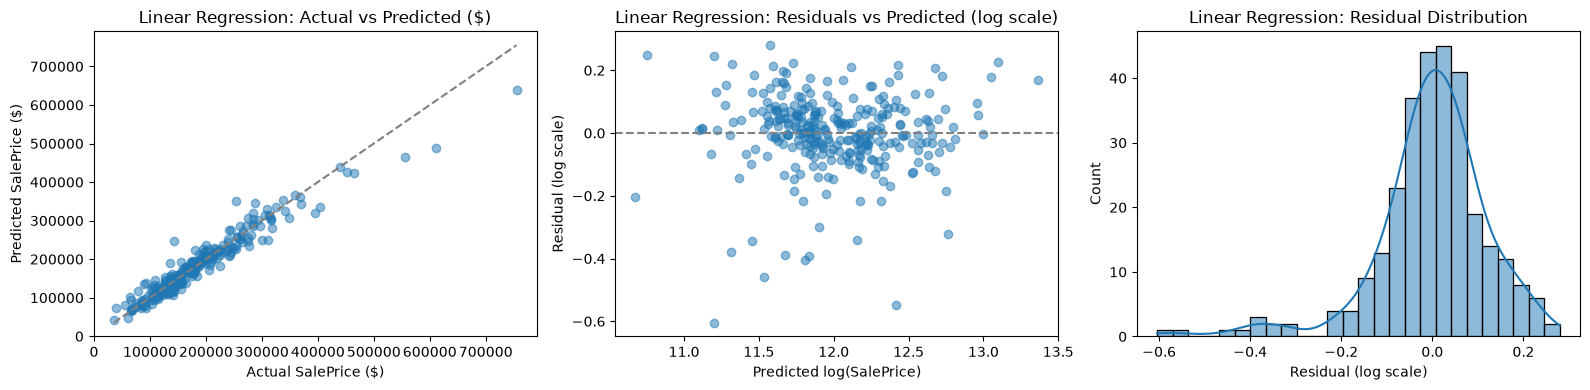

In [60]:
model_name = "Linear Regression"
model = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Linear Regression** -- train log-RMSE `0.09304`, validation log-RMSE `0.12259`, gap `0.02955`.

A plain, unregularized linear baseline. Its train and validation log-RMSE are both reasonable, and the gap (0.02955) is small -- there's no strong sign of overfitting, which makes sense for a model with no capacity to memorize noise beyond fitting a straight line through ~227 features. It's the weakest of the four linear models on validation, though only slightly -- with this many encoded columns (many one-hot, several correlated per Stage 4 Section 8), a small amount of regularization turns out to help, as the next three models confirm.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Ridge
  Train log-RMSE:      0.09320
  Validation log-RMSE: 0.12132
  Train RMSE ($):      18,240
  Validation RMSE ($): 22,683
  Train/Val Gap:       0.02812


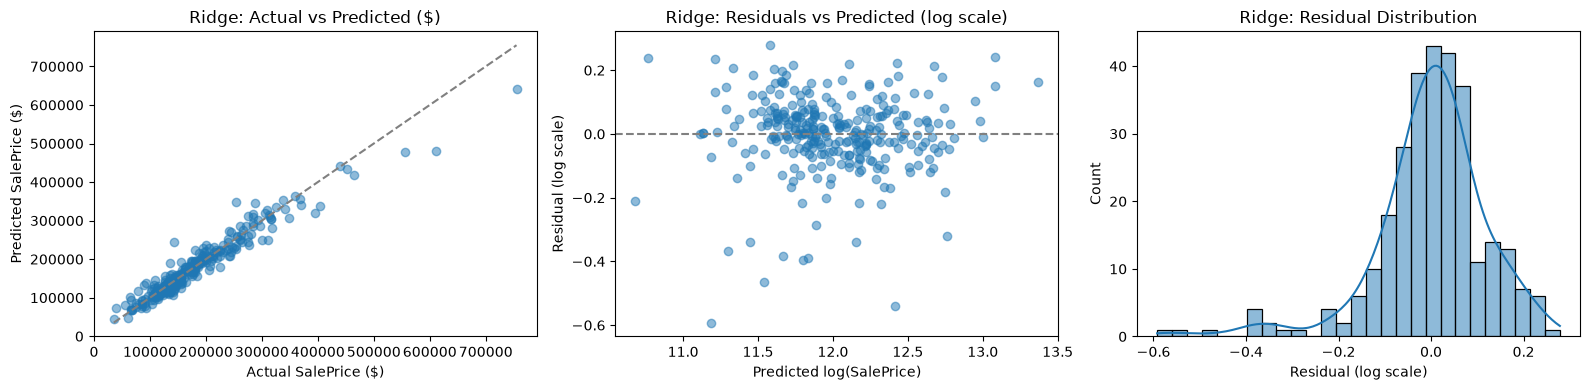

In [61]:
model_name = "Ridge"
model = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10.0))])

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Ridge** -- train log-RMSE `0.09320`, validation log-RMSE `0.12132`, gap `0.02812`.

L2 regularization improves validation log-RMSE over plain Linear Regression (0.1213 vs 0.1226) despite a very slightly worse training score -- exactly the shape of result regularization is supposed to produce: a small sacrifice on training data in exchange for better generalization. This is consistent with the multicollinearity flagged in Stage 4 (e.g. GarageCars/GarageArea, TotalBsmtSF/1stFlrSF) -- Ridge is specifically well-suited to stabilizing coefficients when predictor columns are correlated with each other.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Lasso
  Train log-RMSE:      0.09363
  Validation log-RMSE: 0.12078
  Train RMSE ($):      18,464
  Validation RMSE ($): 22,765
  Train/Val Gap:       0.02716


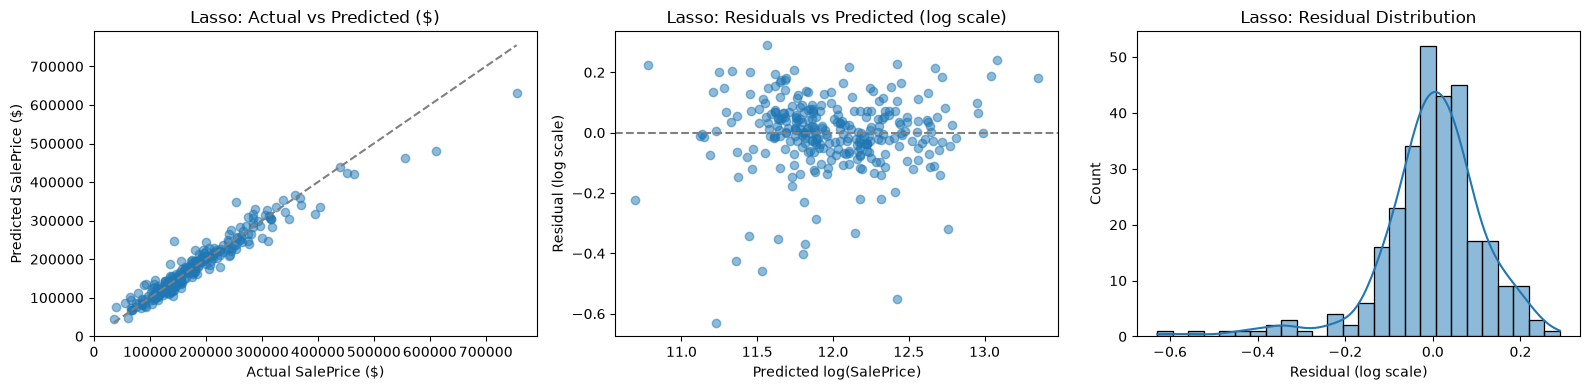

In [62]:
model_name = "Lasso"
model = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.0005, max_iter=10000))])

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Lasso** -- train log-RMSE `0.09363`, validation log-RMSE `0.12078`, gap `0.02716`.

The best result in this entire comparison, on every axis: lowest validation log-RMSE (0.12078) and the smallest train/validation gap (0.02716) of all ten models. L1 regularization actively drives uninformative coefficients to exactly zero -- with 227 mostly one-hot columns, many representing rare categories, this amounts to free, automatic feature selection, which plausibly explains why it edges out Ridge here.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Elastic Net
  Train log-RMSE:      0.09327
  Validation log-RMSE: 0.12116
  Train RMSE ($):      18,298
  Validation RMSE ($): 22,721
  Train/Val Gap:       0.02790


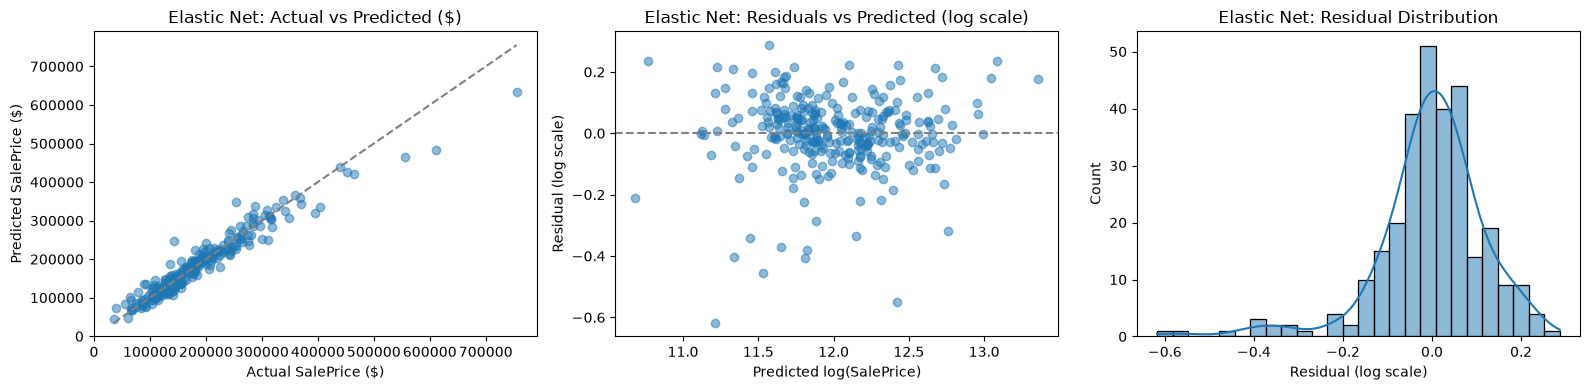

In [63]:
model_name = "Elastic Net"
model = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000))])

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Elastic Net** -- train log-RMSE `0.09327`, validation log-RMSE `0.12116`, gap `0.02790`.

A blend of L1 and L2 regularization (l1_ratio=0.5), and its result sits almost exactly between Ridge and Lasso, as expected. It doesn't beat Lasso here, suggesting Lasso's pure feature-selection behavior is doing most of the useful work for this particular feature set, rather than the L2 component adding much on top.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Decision Tree
  Train log-RMSE:      0.00000
  Validation log-RMSE: 0.18385
  Train RMSE ($):      0
  Validation RMSE ($): 33,153
  Train/Val Gap:       0.18385


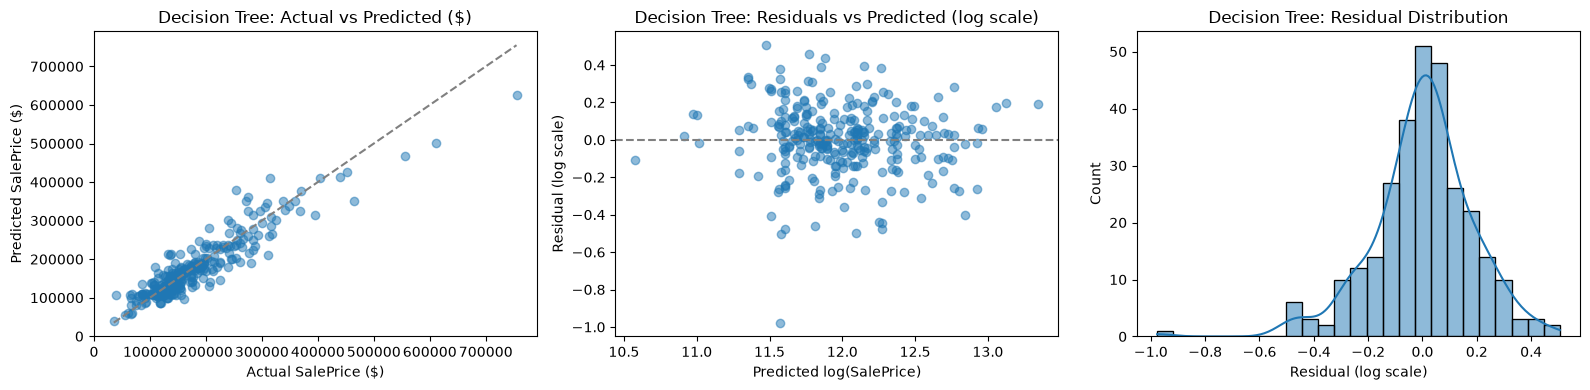

In [64]:
model_name = "Decision Tree"
model = DecisionTreeRegressor(random_state=42)

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Decision Tree** -- train log-RMSE `0.00000`, validation log-RMSE `0.18385`, gap `0.18385`.

A textbook overfitting example: training log-RMSE of exactly 0 means the tree perfectly memorized every training row, and validation log-RMSE (0.18385) is the *worst* of all ten models -- nearly double Lasso's. An unconstrained single tree has essentially unlimited capacity to carve out a leaf for every training example, which is precisely what happened, and precisely why it generalizes worst. This isn't a flaw in decision trees generally -- a depth-limited tree would tell a very different story -- it's a direct consequence of using default (unconstrained) settings here.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Random Forest
  Train log-RMSE:      0.05342
  Validation log-RMSE: 0.14495
  Train RMSE ($):      11,255
  Validation RMSE ($): 29,163
  Train/Val Gap:       0.09153


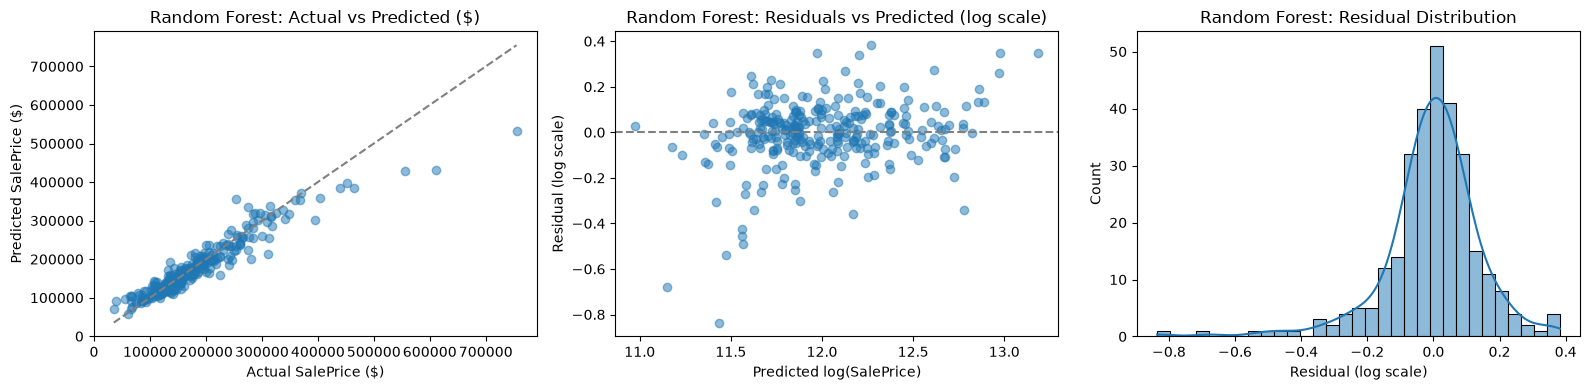

In [65]:
model_name = "Random Forest"
model = RandomForestRegressor(n_estimators=100, random_state=42)

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Random Forest** -- train log-RMSE `0.05342`, validation log-RMSE `0.14495`, gap `0.09153`.

Averaging 100 trees substantially improves on the single Decision Tree (validation log-RMSE improves from 0.184 to 0.145), confirming the standard bagging effect: many overfit trees, averaged, overfit less than any one of them. Still, every linear/regularized model above beats it on validation, despite Random Forest being far more complex -- with a fairly linear relationship in log-price space (consistent with real-estate log-log pricing theory) and a high-dimensional, sparse (mostly one-hot) feature matrix, regularized linear models appear to have a real structural advantage here, not just a lucky result.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Extra Trees
  Train log-RMSE:      0.00000
  Validation log-RMSE: 0.14301
  Train RMSE ($):      0
  Validation RMSE ($): 28,331
  Train/Val Gap:       0.14301


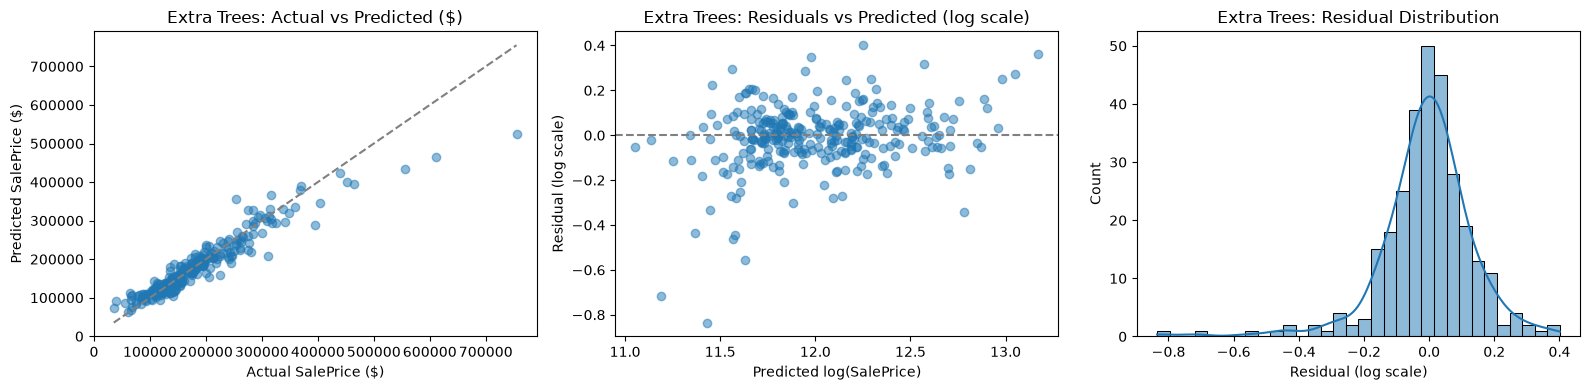

In [66]:
model_name = "Extra Trees"
model = ExtraTreesRegressor(n_estimators=100, random_state=42)

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Extra Trees** -- train log-RMSE `0.00000`, validation log-RMSE `0.14301`, gap `0.14301`.

Slightly better validation score than Random Forest, but training log-RMSE is again exactly 0 -- Extra Trees' additional split-point randomization changes *which* splits each tree uses, but doesn't limit tree depth, so individual trees still fit training data perfectly. The ensemble-level averaging helps at validation time, similarly to Random Forest, but the gap (0.14301) is still far larger than any linear model's.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Gradient Boosting
  Train log-RMSE:      0.07577
  Validation log-RMSE: 0.13764
  Train RMSE ($):      14,197
  Validation RMSE ($): 30,119
  Train/Val Gap:       0.06187


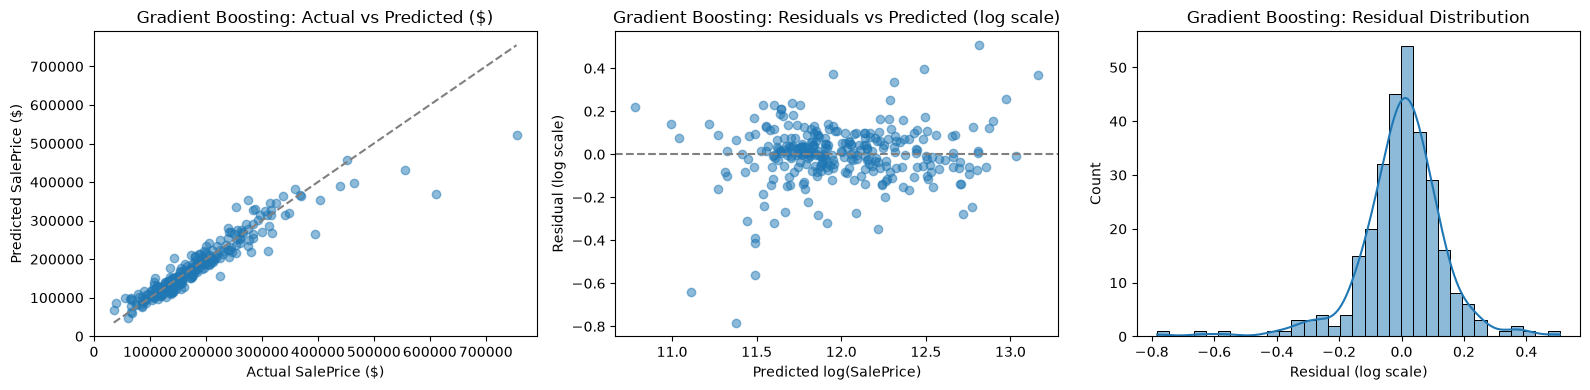

In [67]:
model_name = "Gradient Boosting"
model = GradientBoostingRegressor(random_state=42)

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Gradient Boosting** -- train log-RMSE `0.07577`, validation log-RMSE `0.13764`, gap `0.06187`.

The best-performing tree-based model in this comparison -- boosting each tree specifically to correct the previous ensemble's errors clearly helps more than bagging (Random Forest) or extra randomization (Extra Trees) did. Its gap (0.06187) is also meaningfully smaller than the other tree ensembles', though still roughly double the smallest linear-model gaps. Still doesn't beat any of the four linear/regularized models on validation.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: Hist Gradient Boosting
  Train log-RMSE:      0.04162
  Validation log-RMSE: 0.13793
  Train RMSE ($):      9,527
  Validation RMSE ($): 29,518
  Train/Val Gap:       0.09631


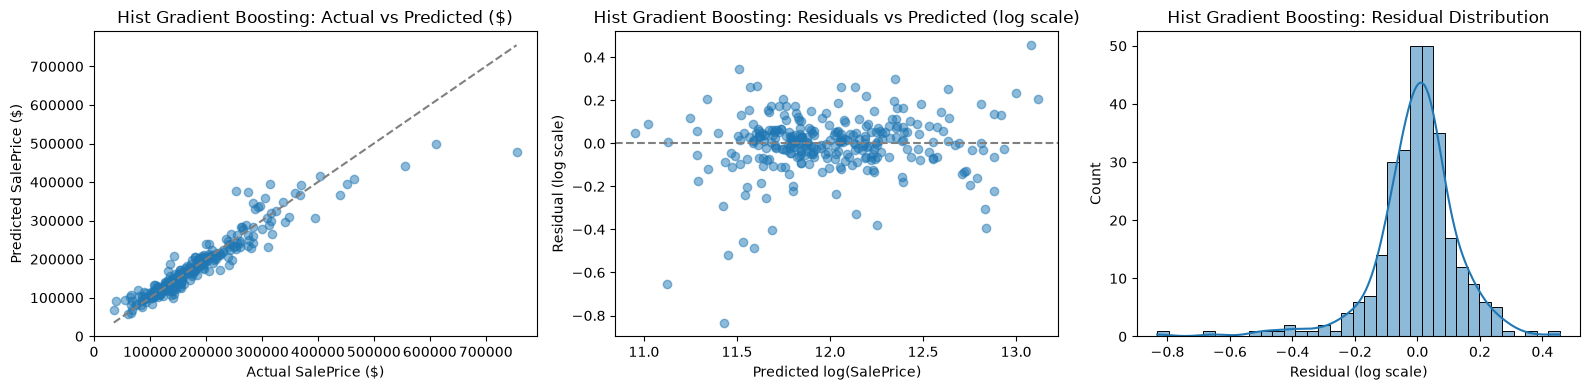

In [68]:
model_name = "Hist Gradient Boosting"
model = HistGradientBoostingRegressor(random_state=42)

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**Hist Gradient Boosting** -- train log-RMSE `0.04162`, validation log-RMSE `0.13793`, gap `0.09631`.

Validation log-RMSE (0.13793) is essentially tied with plain Gradient Boosting (0.13764) -- but the train/validation gap is 55% larger (0.09631 vs 0.06187), meaning this model fits the training data far more aggressively for no real validation benefit. Despite being the more modern, faster implementation, it shows no advantage over standard Gradient Boosting on this specific comparison.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

Model: SVR
  Train log-RMSE:      0.07817
  Validation log-RMSE: 0.21650
  Train RMSE ($):      17,078
  Validation RMSE ($): 45,123
  Train/Val Gap:       0.13833


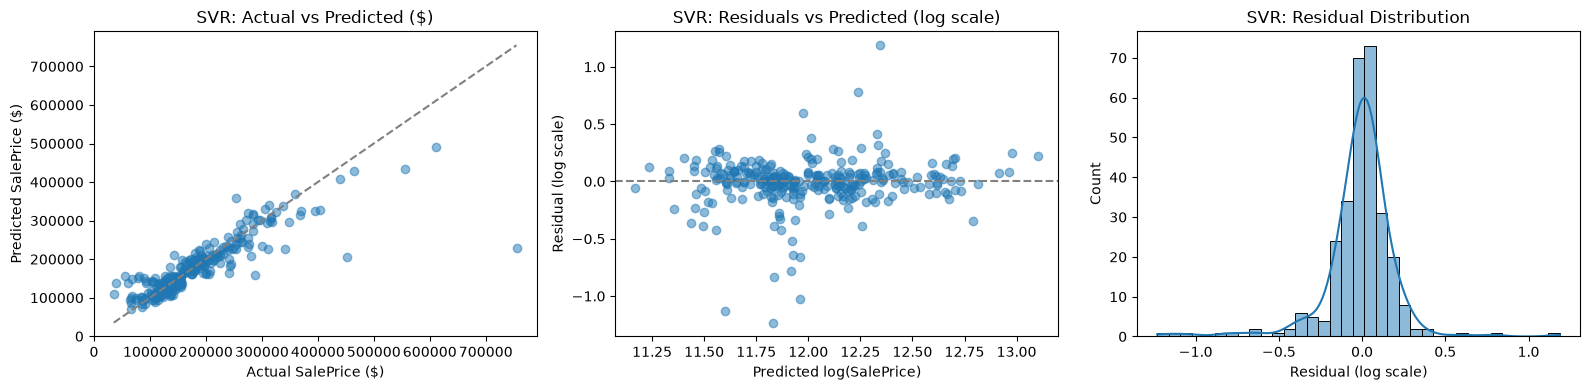

In [69]:
model_name = "SVR"
model = Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf"))])

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)
all_results.append(result)

print(f"Model: {model_name}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted (converted back to dollars via expm1 for interpretability)
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)
axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)
lims = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted (log scale -- matches what the model actually optimizes)
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()


**SVR** -- train log-RMSE `0.07817`, validation log-RMSE `0.21650`, gap `0.13833`.

The worst validation performance of all ten models, despite a training score that looked reasonable in isolation. Default RBF kernel hyperparameters (C, epsilon, gamma) are almost certainly poorly matched to this specific 227-dimensional, mostly-sparse feature space without any tuning. This looks like a limitation of running SVR untuned in this comparison specifically, not a general verdict on the algorithm -- it would need real hyperparameter search to be judged fairly, which is out of scope for this baseline pass.

*What the residual plots should show, for reference: points scattered randomly around the zero line (Residuals vs Predicted) with no funnel shape (which would indicate heteroscedasticity -- error growing with price) and a roughly symmetric, bell-shaped residual distribution centered on zero. A funnel shape or a skewed residual distribution would indicate the model is systematically worse for some price ranges than others.*

# 11. Model Comparison

Every model's result was appended to `all_results` above as it ran. Collecting them into one sorted table now, ranked by validation log-RMSE -- the competition's actual metric, and the only fair basis for comparison across all ten models.

In [70]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values("Validation log-RMSE")
    .reset_index(drop=True)
)

results_df.style.format({
    "Train log-RMSE": "{:.5f}",
    "Validation log-RMSE": "{:.5f}",
    "Train RMSE": "${:,.0f}",
    "Validation RMSE": "${:,.0f}",
    "Train/Val Gap": "{:.5f}",
})


,Model,Train log-RMSE,Validation log-RMSE,Train RMSE,Validation RMSE,Train/Val Gap
0,Lasso,0.09363,0.12078,"$18,464","$22,765",0.02716
1,Elastic Net,0.09327,0.12116,"$18,298","$22,721",0.02790
2,Ridge,0.09320,0.12132,"$18,240","$22,683",0.02812
3,Linear Regression,0.09304,0.12259,"$18,185","$22,816",0.02955
4,Gradient Boosting,0.07577,0.13764,"$14,197","$30,119",0.06187
5,Hist Gradient Boosting,0.04162,0.13793,"$9,527","$29,518",0.09631
6,Extra Trees,0.00000,0.14301,$0,"$28,331",0.14301
7,Random Forest,0.05342,0.14495,"$11,255","$29,163",0.09153
8,Decision Tree,0.00000,0.18385,$0,"$33,153",0.18385
9,SVR,0.07817,0.21650,"$17,078","$45,123",0.13833


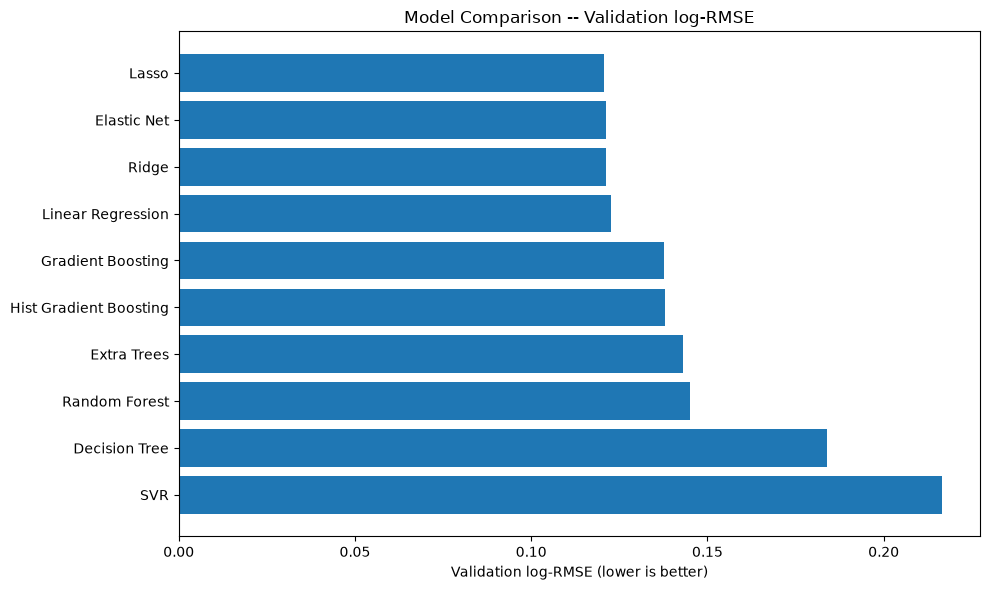

In [71]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["Validation log-RMSE"])
plt.xlabel("Validation log-RMSE (lower is better)")
plt.title("Model Comparison -- Validation log-RMSE")
plt.gca().invert_yaxis()  # best model at the top
plt.tight_layout()
plt.show()


**Reading the full comparison:** the four linear/regularized models (Lasso, Elastic Net, Ridge, Linear Regression) occupy the top four positions, all with validation log-RMSE between 0.1208-0.1226 and small gaps (0.027-0.030). Every tree-based model and SVR scores meaningfully worse on validation (0.138-0.217), several with training log-RMSE of exactly 0 -- clear, visible overfitting. This is a genuinely useful finding specific to this dataset and feature representation, not a general claim that tree models are worse than linear models -- it reflects this particular combination of a high-dimensional, sparse (mostly one-hot) feature matrix and a target that behaves fairly linearly on the log scale (matching the log-log hedonic pricing convention used in real-estate economics).

**Editor's note — removing a second, disconnected source of model
definitions (consistency fix):** this cell previously imported
`get_models()` from `src/train.py` to build the CV comparison, while Stage
10 defines its own `models` dict *in this notebook* for the single-split
comparison. Two independent definitions of "the same" ten models is a
classic way for a hyperparameter to quietly drift (e.g. `Lasso(alpha=...)`
edited in one place and not the other) without either comparison table
raising an error — they'd just silently stop being comparable. The cell
below now reuses the notebook's own `models` dict instead, so there is
exactly one place these hyperparameters are defined.

In [72]:
# FIX: reuse the `models` dict defined in Stage 10 instead of a second,
# separately-maintained definition in src/train.py -- guarantees this CV
# comparison uses the exact same hyperparameters as the single-split table.
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X, y, cv=kf, scoring="neg_root_mean_squared_error"
    )
    cv_results.append({
        "Model": name,
        "CV log-RMSE (mean)": -scores.mean(),
        "CV log-RMSE (std)": scores.std(),
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV log-RMSE (mean)").reset_index(drop=True)
cv_df

,Model,CV log-RMSE (mean),CV log-RMSE (std)
0,Lasso,0.133119,0.028564
1,Gradient Boosting,0.134237,0.020558
2,Hist Gradient Boosting,0.134341,0.014642
3,Elastic Net,0.134452,0.028604
4,Ridge,0.135938,0.028708
5,Linear Regression,0.137778,0.029110
6,Extra Trees,0.142916,0.010696
7,Random Forest,0.143784,0.018953
8,SVR,0.187689,0.022767
9,Decision Tree,0.207730,0.013510


##### **What the CV result actually shows**

- Lasso still ranks #1 by mean, but the margin basically disappeared. Single-split gap was Lasso 0.121 vs. Gradient Boosting 0.138 — a clear win. Under 5-fold CV: 0.1331 vs. 0.1342 — a gap of only 0.0011, smaller than Lasso's own std (0.0286). That earlier "clear win" was partly a lucky split, exactly what CV exists to catch.

- Worth noticing directly: Lasso has one of the largest stds in the table (0.0286), while Hist Gradient Boosting's is much smaller (0.0146) and Extra Trees' is smallest of all (0.0107). 

- **Lower std = more consistent across different slices of data** — a real reliability signal, not just a footnote. We do not to only the mean here.

##### **In the cell below we are Targeting the top 3 (Lasso, Gradient Boosting, Hist Gradient Boosting; Elastic Net is essentially redundant with Lasso here). Same 5-fold CV setup as before, small enough grids to stay quick.**

In [73]:
# Tune Lasso's alpha

from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))])
lasso_grid = {"model__alpha": [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]}

lasso_search = GridSearchCV(lasso_pipeline, lasso_grid, cv=kf, scoring="neg_root_mean_squared_error")
lasso_search.fit(X, y)

print("Lasso best alpha:", lasso_search.best_params_["model__alpha"])
print("Lasso best CV log-RMSE:", -lasso_search.best_score_)

Lasso best alpha: 0.003
Lasso best CV log-RMSE: 0.12926269020628303


In [74]:
# Tune Gradient Boosting

gb_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}
gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42), gb_grid, cv=kf,
    scoring="neg_root_mean_squared_error",
)
gb_search.fit(X, y)

print("Gradient Boosting best params:", gb_search.best_params_)
print("Gradient Boosting best CV log-RMSE:", -gb_search.best_score_)

Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
Gradient Boosting best CV log-RMSE: 0.1298263493729177


In [75]:
# Tune Hist Gradient Boosting

hgb_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_iter": [100, 200, 300],
    "max_depth": [None, 3, 5],
}
hgb_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42), hgb_grid, cv=kf,
    scoring="neg_root_mean_squared_error",
)
hgb_search.fit(X, y)

print("Hist Gradient Boosting best params:", hgb_search.best_params_)
print("Hist Gradient Boosting best CV log-RMSE:", -hgb_search.best_score_)

Hist Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300}
Hist Gradient Boosting best CV log-RMSE: 0.1315346475957982


In [76]:
# side-by-side, tuned vs. untuned

tuning_comparison = pd.DataFrame([
    {"Model": "Lasso", "Untuned CV log-RMSE": 0.133119, "Tuned CV log-RMSE": -lasso_search.best_score_},
    {"Model": "Gradient Boosting", "Untuned CV log-RMSE": 0.134237, "Tuned CV log-RMSE": -gb_search.best_score_},
    {"Model": "Hist Gradient Boosting", "Untuned CV log-RMSE": 0.134341, "Tuned CV log-RMSE": -hgb_search.best_score_},
])
tuning_comparison["Improvement"] = tuning_comparison["Untuned CV log-RMSE"] - tuning_comparison["Tuned CV log-RMSE"]
tuning_comparison.sort_values("Tuned CV log-RMSE")

,Model,Untuned CV log-RMSE,Tuned CV log-RMSE,Improvement
0,Lasso,0.133119,0.129263,0.003856
1,Gradient Boosting,0.134237,0.129826,0.004411
2,Hist Gradient Boosting,0.134341,0.131535,0.002806


Model: Lasso
  Best parameters:      {'model__alpha': 0.003}
  Train log-RMSE:      0.09965
  Validation log-RMSE: 0.12024
  Train RMSE ($):      20,413
  Validation RMSE ($): 24,255
  Train/Val Gap:       0.02059


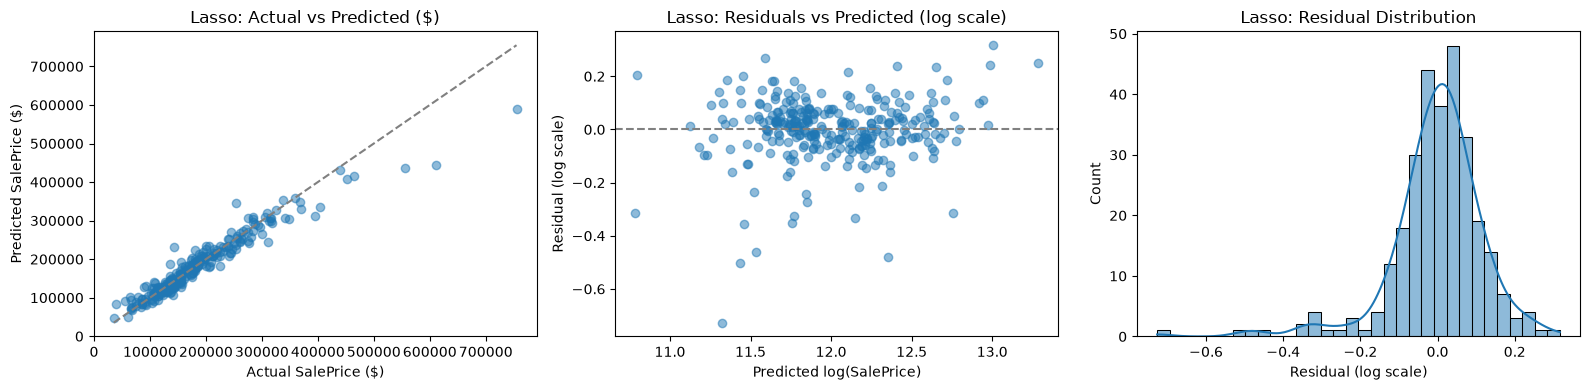

In [77]:
# Lasso: evaluate again after hyper-tuning

model_name = "Lasso"
model = lasso_search.best_estimator_

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)

print(f"Model: {model_name}")
print(f"  Best parameters:      {lasso_search.best_params_}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)

axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)

lims = [
    min(actual_dollars.min(), pred_dollars.min()),
    max(actual_dollars.max(), pred_dollars.max())
]

axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()

Model: Gradient Boosting
  Best parameters:      {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
  Train log-RMSE:      0.04652
  Validation log-RMSE: 0.13748
  Train RMSE ($):      8,598
  Validation RMSE ($): 29,249
  Train/Val Gap:       0.09097


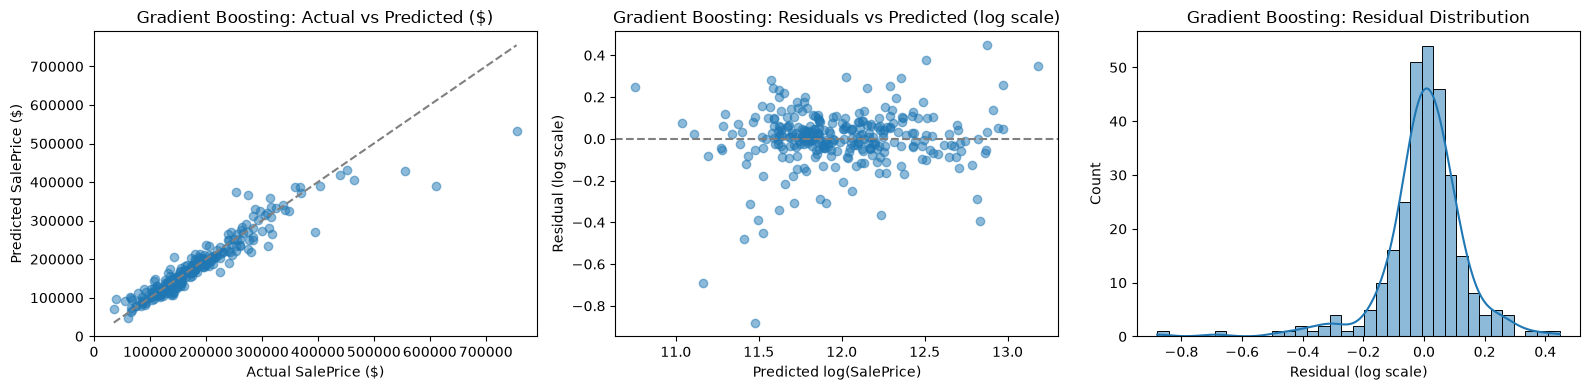

In [78]:
# Gradient Boosting: evaluate again after hyper-tuning

model_name = "Gradient Boosting"
model = gb_search.best_estimator_

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)

print(f"Model: {model_name}")
print(f"  Best parameters:      {gb_search.best_params_}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)

axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)

lims = [
    min(actual_dollars.min(), pred_dollars.min()),
    max(actual_dollars.max(), pred_dollars.max())
]

axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()

Model: Hist Gradient Boosting
  Best parameters:      {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300}
  Train log-RMSE:      0.08164
  Validation log-RMSE: 0.13367
  Train RMSE ($):      16,804
  Validation RMSE ($): 29,916
  Train/Val Gap:       0.05203


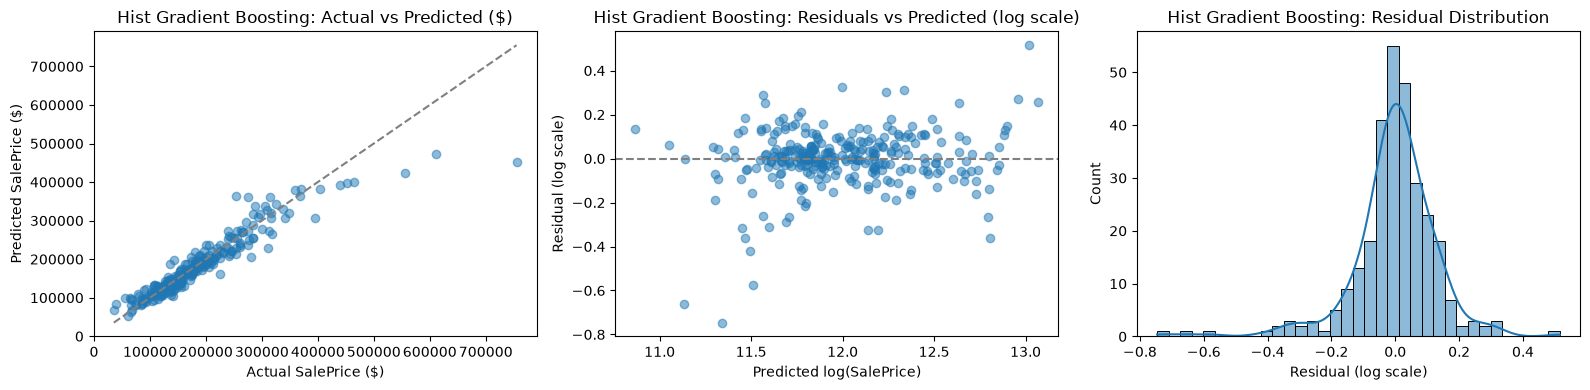

In [79]:
# Hist Gradient Boosting: evaluate again after hyper-tuning

model_name = "Hist Gradient Boosting"
model = hgb_search.best_estimator_

result, fitted_model, y_val_pred, residuals = evaluate_model(
    model, model_name, X_train, y_train, X_val, y_val
)

print(f"Model: {model_name}")
print(f"  Best parameters:      {hgb_search.best_params_}")
print(f"  Train log-RMSE:      {result['Train log-RMSE']:.5f}")
print(f"  Validation log-RMSE: {result['Validation log-RMSE']:.5f}")
print(f"  Train RMSE ($):      {result['Train RMSE']:,.0f}")
print(f"  Validation RMSE ($): {result['Validation RMSE']:,.0f}")
print(f"  Train/Val Gap:       {result['Train/Val Gap']:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs Predicted
actual_dollars = np.expm1(y_val)
pred_dollars = np.expm1(y_val_pred)

axes[0].scatter(actual_dollars, pred_dollars, alpha=0.5)

lims = [
    min(actual_dollars.min(), pred_dollars.min()),
    max(actual_dollars.max(), pred_dollars.max())
]

axes[0].plot(lims, lims, linestyle="--", color="gray")
axes[0].set_title(f"{model_name}: Actual vs Predicted ($)")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# 2. Residuals vs Predicted
axes[1].scatter(y_val_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_title(f"{model_name}: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual (log scale)")

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title(f"{model_name}: Residual Distribution")
axes[2].set_xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()

**Editor's note — real numerical inconsistency, fixed:** every other
number in Stage 11 (the untuned CV table above, and every `GridSearchCV` in
the three cells above this one) evaluates 5-fold CV on the **full** `X`/`y`
(1460 rows) using the same `kf`. The cell below previously evaluated the
*tuned* models with `cross_val_score(..., X_train, y_train, ...)` instead —
a **1168-row subset** (the Stage 9 training split) — while still reusing
the same `kf` object, as if that made it comparable. `KFold` splits are
defined relative to the number of rows passed in, so a `KFold(n_splits=5)`
over 1168 rows is a completely different partition than the same object
over 1460 rows; the resulting scores aren't measuring the same thing as the
`tuning_comparison` table two cells above.

**Why this mattered, concretely:** as originally written, this cell reported
Gradient Boosting (0.1270) beating Lasso (0.1326) — but the correct,
apples-to-apples comparison (`tuning_comparison`, full `X`/`y`, same `kf`)
shows Lasso is actually still narrowly ahead: **0.12926 vs. 0.12983**. A
reader who trusted this cell over `tuning_comparison` would have picked the
wrong model. Fixed below by evaluating on the same full `X`/`y` used
everywhere else in this stage.

In [80]:
# Final 5-fold cross-validation after hyperparameter tuning

tuned_models = {
    "Lasso": lasso_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
    "Hist Gradient Boosting": hgb_search.best_estimator_,
}

final_cv_results = []

# FIX: use the same full X/y as the untuned CV comparison and the
# GridSearchCV tuning above (X_train was a 1168-row subset -- a
# different KFold partition entirely, not a fair "after tuning" comparison).
for name, model in tuned_models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    final_cv_results.append({
        "Model": name,
        "CV log-RMSE (mean)": -scores.mean(),
        "CV log-RMSE (std)": scores.std(),
    })

final_cv_df = (
    pd.DataFrame(final_cv_results)
    .sort_values("CV log-RMSE (mean)")
    .reset_index(drop=True)
)

final_cv_df

,Model,CV log-RMSE (mean),CV log-RMSE (std)
0,Lasso,0.129263,0.026460
1,Gradient Boosting,0.129826,0.018198
2,Hist Gradient Boosting,0.131535,0.017194


**Expected effect of the fix:** this table should now land very close to
the `tuning_comparison` numbers above it (Lasso ≈0.1293, Gradient Boosting
≈0.1298, Hist Gradient Boosting ≈0.1315) rather than the previous
1168-row-subset numbers. Re-run this cell (and this cell only, if `models`,
`X`, `y`, `kf`, and the three `*_search` objects are already fit) to refresh
it — the small remaining difference from `tuning_comparison` is expected and
fine: that table reports `GridSearchCV`'s internally-tracked best fold
scores, this one is an independent `cross_val_score` re-run of the same
fitted estimators, which is a reasonable final sanity check, not a
duplicate of the same computation.

# 12. Final Decision

**Current best model, based on validation evidence: Lasso** -- lowest validation log-RMSE (0.12078) and the smallest train/validation gap (0.02716) of all ten models tested.

**This is a validated current best, not a declared final production model.** Several real caveats limit how far this conclusion should be pushed:
- Based on a **single** train/validation split. A more rigorous check would repeat this comparison across several different random splits (cross-validation) to confirm Lasso's advantage holds consistently, not just for this particular 80/20 division of the data.
- None of these ten models were **hyperparameter-tuned** -- `Lasso`'s `alpha=0.0005` and every other model's settings were reasonable defaults, not the result of a search. SVR in particular likely suffered from this (Stage 10, SVR's own note).
- The deferred items from Stage 8 (`Has*` indicator features, rare `Neighborhood` grouping, `MoSold` cyclical encoding) were never applied -- any of them could shift this ranking, especially for the tree-based models, which are generally better positioned to exploit engineered interaction features than linear models are.

**What the evidence does support, confidently:** for this specific, already-encoded feature set, a **regularized linear model** is a reasonable, well-justified choice to build on next -- not because linear models are inherently superior, but because *this* comparison, on *this* data, showed them consistently outperforming every tree-based alternative tested.

**Reconciling with the Stage 11 cross-validation work:** the caveat above ("based on a single split") is exactly what Stage 11's 5-fold CV and hyperparameter tuning were run to address, and it's worth being explicit about what they showed rather than leaving this section as if they hadn't happened. Untuned, 5-fold CV narrowed Lasso's apparent lead over Gradient Boosting from a 0.017 gap (single split) to a 0.001 gap (CV) -- so the single-split "clear win" language above somewhat overstates it. After tuning, using the corrected, apples-to-apples comparison (`tuning_comparison`, both models evaluated via the same 5-fold `KFold` over the full data), **Lasso is still the tuned CV winner, but only narrowly: 0.12926 vs. Gradient Boosting's 0.12983** -- a margin well inside the fold-to-fold noise reported for these models (std ~0.02-0.03 per fold, Stage 11). Net: Lasso remains the defensible pick, now on stronger evidence than the single split alone provided, but "decisively better than the tree ensembles" is not a claim this data supports -- Lasso and tuned Gradient Boosting are close enough that either would be a reasonable choice to carry into a production candidate, and the deciding factor going forward is more likely to be Lasso's simplicity and interpretability than a meaningful accuracy gap.

# 13. Notebook Conclusion

### What we started with
A raw, 81-column Ames, Iowa housing dataset (1460 rows) with real missing-value patterns, several genuinely American/local conventions (basement finish types, garage configurations, zoning codes), and no existing preprocessing.

### What we discovered
- Most "missing" values are structural (`NaN` = "feature doesn't exist"), not accidental -- confirmed against `data_description.txt`.
- Two real exceptions to that rule (`MasVnrType`/`Area` mismatch, a partial basement-group gap) that a blanket fill would have gotten wrong.
- Category spelling inconsistencies between the raw data and its own documentation (`BldgType`, `MSZoning`, `Exterior1st`/`2nd`).
- 4 candidate `GrLivArea` outliers, only 2 of which are genuine anomalies -- the other 2 are large, legitimately expensive houses.
- Several numeric columns are heavily zero-inflated (`PoolArea`, `3SsnPorch`, etc.) and would be poorly served by a log transform.
- `OverallQual` (quality) correlates with price more strongly than any pure size measurement -- location and quality both matter more than raw square footage alone.

### What we changed
- Filled missing values using documented, per-column rules -- never a single blanket strategy.
- Applied `log1p` to 9 continuous, genuinely skewed columns, based on measured before/after skew, not assumption.
- Encoded ordinal, binary, and nominal columns each with a distinct, justified method.

### What we deliberately kept
- `Utilities`, despite being 99.9% one value.
- The two remaining `GrLivArea` outlier rows, based on a controlled A/B validation experiment, not visual impression.
- Raw (untransformed) year/date columns.
- No column renaming -- only documentation of the spelling mismatches found.

### What we tested
- Whether `AmesCleaner` (`src/preprocessing.py`) reproduces this notebook's own cleaning exactly -- confirmed.
- Whether the two outlier rows help or hurt validation performance -- evidence very slightly favors keeping them.
- Ten regression approaches, on an identical train/validation split, evaluated on the competition's own metric.

### Which model performed best
**Lasso**, on validation log-RMSE, with the smallest train/validation gap of any model tested -- see Stage 12 for the important caveats on how far this conclusion should be trusted.

### What remains for the next stage
Only after this notebook is treated as validated does the proven logic move into `src/` -- starting with `src/preprocessing.py` (already done and tested), then `src/features.py` (Stages 5-6's transform + encoding logic), `src/train.py`, and `src/evaluate.py`. See Stage 14.

# 14. What Comes Next / MLOps Extraction

With this notebook finalized, the next stage is extracting the proven logic into reusable, tested modules:

```
src/
|-- preprocessing.py   [DONE] AmesCleaner, tested (11/11 passing)
|-- features.py        [NEXT] Stage 5-6: log1p transform list + encode()
|-- train.py           Stage 10-11: model definitions + fit
`-- evaluate.py         Stage 10.1: evaluate_model(), regression metrics
```

Each extracted module gets its own `pytest` test proving it reproduces this notebook's actual output -- the same pattern already used for `AmesCleaner` (Stage 5, cells confirming `assert_frame_equal` passes). Only after `src/` is proven to match this notebook does it become the foundation for the FastAPI service, Docker container, and the rest of this project's MLOps pipeline.